# Polybag Detection Pipeline: YOLOv11-OBB + SAM + Dice Evaluation

This notebook implements a complete pipeline for:
1. **Training YOLOv11-OBB** on polybag images using JSON annotations
2. **SAM (Segment Anything Model)** integration for mask generation
3. **Dice Coefficient** calculation to evaluate segmentation quality

All functions are implemented directly in this notebook - no external imports required.

## 1. Imports and Environment Setup

In [ ]:
# Core imports
import csv
import json
import re
import time
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.optimize import linear_sum_assignment

# Ultralytics for YOLO and SAM
from ultralytics import SAM, YOLO

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA A40


## 2. Configuration Paths

Set all paths relative to the dataset root directory.

In [3]:
# ===================== CONFIGURATION =====================
# Source data (raw, unsplit)
SOURCE_ROOT = Path("/home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool")
SOURCE_IMAGES = SOURCE_ROOT / "images/0000"
SOURCE_LABELS = SOURCE_ROOT / "output/labels"
SOURCE_JSONS = SOURCE_ROOT / "output/jsons"

# Working directory (where we'll create train/val split)
DATA_ROOT = SOURCE_ROOT / "dataset_split"

# These will be created by the split function
IMAGES_TRAIN = DATA_ROOT / "images/train"
IMAGES_VAL = DATA_ROOT / "images/val"
LABELS_TRAIN = DATA_ROOT / "labels/train"
LABELS_VAL = DATA_ROOT / "labels/val"
DATA_CONFIG = DATA_ROOT / "polybag_dataset.yaml"

# Model paths
PRETRAINED_WEIGHTS = Path("/home/xegi09mi/19-01-2026_Database/polybag_dataset_yolo_obb/yolo11s-obb.pt")
RUNS_DIR = DATA_ROOT / "runs"
OBB_RUN_DIR = RUNS_DIR / "obb"
AUTO_LABEL_DIR = DATA_ROOT / "labels/auto"
REFERENCE_MASK_DIR = DATA_ROOT / "reference_masks"

# SAM checkpoints (download if needed) - check both locations
SAM_BASE = Path("/home/xegi09mi/19-01-2026_Database/polybag_dataset_yolo_obb")
SAM_CHECKPOINTS = {
    "sam2.1_b": SAM_BASE / "sam2.1_b.pt",
    "sam2_s": SAM_BASE / "sam2_s.pt",
    "sam3_b": Path("/home/xegi09mi/sam3_b.pt"),
}

# Verify source paths
print("📁 Source Data Structure:")
print(f"  Source root: {SOURCE_ROOT} (exists: {SOURCE_ROOT.exists()})")
print(f"  Images: {SOURCE_IMAGES} (exists: {SOURCE_IMAGES.exists()})")
print(f"  Labels: {SOURCE_LABELS} (exists: {SOURCE_LABELS.exists()})")
print(f"  JSONs: {SOURCE_JSONS} (exists: {SOURCE_JSONS.exists()})")

# Count source files
if SOURCE_IMAGES.exists():
    num_images = len(list(SOURCE_IMAGES.glob("*.png")))
    print(f"\n📊 Found {num_images} source images")
if SOURCE_LABELS.exists():
    num_labels = len(list(SOURCE_LABELS.glob("*.txt")))
    print(f"📊 Found {num_labels} source labels")

📁 Source Data Structure:
  Source root: /home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool (exists: True)
  Images: /home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool/images/0000 (exists: True)
  Labels: /home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool/output/labels (exists: True)
  JSONs: /home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool/output/jsons (exists: True)

📊 Found 434 source images
📊 Found 434 source labels


## 3. Data Splitting and YAML Generation

Split the dataset into train/val sets and create the YOLO config file.

In [4]:
import shutil
import random

def split_dataset(
    source_images: Path,
    source_labels: Path,
    output_root: Path,
    val_ratio: float = 0.2,
    seed: int = 42,
) -> Dict[str, int]:
    """
    Split dataset into train/val sets.
    
    Args:
        source_images: Directory with all images
        source_labels: Directory with all labels
        output_root: Root directory for split dataset
        val_ratio: Fraction of data for validation (default 0.2 = 20%)
        seed: Random seed for reproducibility
        
    Returns:
        Summary dict with counts
    """
    print("=" * 60)
    print("📂 SPLITTING DATASET INTO TRAIN/VAL")
    print("=" * 60)
    
    # Create output directories
    train_img_dir = output_root / "images/train"
    val_img_dir = output_root / "images/val"
    train_lbl_dir = output_root / "labels/train"
    val_lbl_dir = output_root / "labels/val"
    
    for d in [train_img_dir, val_img_dir, train_lbl_dir, val_lbl_dir]:
        d.mkdir(parents=True, exist_ok=True)
    
    # Get all image files
    image_files = sorted(source_images.glob("*.png"))
    if not image_files:
        image_files = sorted(source_images.glob("*.jpg"))
    
    print(f"  Found {len(image_files)} images")
    
    # Filter to images that have corresponding labels
    valid_pairs = []
    for img_path in image_files:
        label_path = source_labels / f"{img_path.stem}.txt"
        if label_path.exists():
            valid_pairs.append((img_path, label_path))
    
    print(f"  Found {len(valid_pairs)} image-label pairs")
    
    # Shuffle and split
    random.seed(seed)
    random.shuffle(valid_pairs)
    
    val_count = int(len(valid_pairs) * val_ratio)
    val_pairs = valid_pairs[:val_count]
    train_pairs = valid_pairs[val_count:]
    
    print(f"  Train: {len(train_pairs)}, Val: {len(val_pairs)}")
    
    # Copy files
    for img_path, lbl_path in train_pairs:
        shutil.copy2(img_path, train_img_dir / img_path.name)
        shutil.copy2(lbl_path, train_lbl_dir / lbl_path.name)
    
    for img_path, lbl_path in val_pairs:
        shutil.copy2(img_path, val_img_dir / img_path.name)
        shutil.copy2(lbl_path, val_lbl_dir / lbl_path.name)
    
    print(f"\n✅ Dataset split complete!")
    print(f"   Train images: {train_img_dir}")
    print(f"   Val images: {val_img_dir}")
    
    return {
        "total": len(valid_pairs),
        "train": len(train_pairs),
        "val": len(val_pairs),
    }


def create_yolo_yaml(
    output_path: Path,
    data_root: Path,
    class_names: List[str],
) -> Path:
    """
    Create YOLO dataset configuration YAML file.
    
    Args:
        output_path: Path to save YAML file
        data_root: Root directory of the dataset
        class_names: List of class names
        
    Returns:
        Path to created YAML file
    """
    yaml_content = f"""# Polybag Dataset Configuration
# Auto-generated for YOLOv11-OBB training

path: {data_root}
train: images/train
val: images/val

# Number of classes
nc: {len(class_names)}

# Class names
names:
"""
    for i, name in enumerate(class_names):
        yaml_content += f"  {i}: {name}\n"
    
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, 'w') as f:
        f.write(yaml_content)
    
    print(f"✅ Created YAML config: {output_path}")
    return output_path

print("✅ Data splitting functions defined")

✅ Data splitting functions defined


In [5]:
# ============ RUN DATA SPLIT ============
# Set to False if already split
RUN_SPLIT = True
VAL_RATIO = 0.2  # 20% for validation

if RUN_SPLIT:
    # Check if split already exists
    if IMAGES_TRAIN.exists() and len(list(IMAGES_TRAIN.glob("*.png"))) > 0:
        print("⚠️ Dataset already split! Skipping...")
        print(f"   Train images: {len(list(IMAGES_TRAIN.glob('*.png')))}")
        print(f"   Val images: {len(list(IMAGES_VAL.glob('*.png')))}")
    else:
        # Run the split
        split_summary = split_dataset(
            source_images=SOURCE_IMAGES,
            source_labels=SOURCE_LABELS,
            output_root=DATA_ROOT,
            val_ratio=VAL_RATIO,
            seed=42,
        )
        print(f"\n📊 Split Summary: {split_summary}")

# Create YAML config
CLASS_NAMES = ["polybag"]  # Single class for this dataset

create_yolo_yaml(
    output_path=DATA_CONFIG,
    data_root=DATA_ROOT,
    class_names=CLASS_NAMES,
)

# Create other directories
for directory in (RUNS_DIR, OBB_RUN_DIR, AUTO_LABEL_DIR, REFERENCE_MASK_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"\n📄 YAML config saved to: {DATA_CONFIG}")

⚠️ Dataset already split! Skipping...
   Train images: 348
   Val images: 86
✅ Created YAML config: /home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool/dataset_split/polybag_dataset.yaml

📄 YAML config saved to: /home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool/dataset_split/polybag_dataset.yaml


## 4. Dataset Discovery

Find all training and validation images.

In [6]:
def discover_images(directory: Path, extensions: tuple = (".png", ".jpg", ".jpeg")) -> List[Path]:
    """Find all image files in a directory."""
    images = []
    for ext in extensions:
        images.extend(directory.glob(f"*{ext}"))
    return sorted(images)

# Discover images
train_images = discover_images(IMAGES_TRAIN)
val_images = discover_images(IMAGES_VAL)
all_images = train_images + val_images

print(f"📊 Dataset Summary:")
print(f"  Training images: {len(train_images)}")
print(f"  Validation images: {len(val_images)}")
print(f"  Total images: {len(all_images)}")

if train_images:
    SAMPLE_IMAGE = train_images[0]
    print(f"\n📷 Sample image: {SAMPLE_IMAGE.name}")
else:
    SAMPLE_IMAGE = None
    print("⚠️ No training images found!")

📊 Dataset Summary:
  Training images: 348
  Validation images: 86
  Total images: 434

📷 Sample image: 001400.png


## 5. SAMVariant Data Class

Simple container to describe SAM model checkpoints.

In [7]:
@dataclass
class SAMVariant:
    """Container describing a SAM checkpoint."""
    name: str
    checkpoint: Path
    
    def exists(self) -> bool:
        """Check if checkpoint file exists."""
        return self.checkpoint.exists()
    
    def __repr__(self):
        status = "✅" if self.exists() else "❌"
        return f"SAMVariant({self.name}, {self.checkpoint.name}) {status}"

## 6. Device Resolution Utility

In [8]:
def resolve_device(device: Optional[str] = None) -> str:
    """Determine the best available device (CUDA or CPU)."""
    if device:
        return device
    return "cuda" if torch.cuda.is_available() else "cpu"

# Test device
device = resolve_device()
print(f"🖥️ Using device: {device}")

🖥️ Using device: cuda


## 7. YOLOv11-OBB + SAM Detector Class

This is the main class that combines YOLOv11-OBB detection with SAM segmentation.

In [9]:
class YOLOv11_OBB_SAM_Detector:
    """
    Fuse YOLOv11-OBB detections with SAM masks.
    
    This class:
    - Runs YOLOv11-OBB to detect oriented bounding boxes
    - Uses SAM to generate precise segmentation masks from detected boxes
    - Provides visualization and annotation export utilities
    """

    def __init__(
        self,
        yolo_model_path: Path,
        sam_model_path: Path,
        device: Optional[str] = None,
        conf_threshold: float = 0.5,
    ) -> None:
        """
        Initialize the detector.
        
        Args:
            yolo_model_path: Path to YOLOv11-OBB weights
            sam_model_path: Path to SAM checkpoint
            device: 'cuda' or 'cpu' (auto-detected if None)
            conf_threshold: Confidence threshold for detections
        """
        self.device = resolve_device(device)
        self.conf_threshold = conf_threshold

        print(f"Loading YOLO model from {yolo_model_path}...")
        self.yolo_model = YOLO(str(yolo_model_path))
        
        print(f"Loading SAM model from {sam_model_path}...")
        self.sam_model = SAM(str(sam_model_path))

        # Move models to device
        if self.device.startswith("cuda") and torch.cuda.is_available():
            self.yolo_model.to(self.device)
            self.sam_model.to(self.device)
        
        print(f"✅ Models loaded on {self.device}")

    @staticmethod
    def _ensure_2d(mask: np.ndarray) -> np.ndarray:
        """Ensure mask is 2D by squeezing extra dimensions."""
        return mask.squeeze() if mask.ndim == 3 else mask

    def detect_objects(self, image: np.ndarray) -> Dict:
        """
        Run YOLOv11-OBB detection on an image.
        
        Returns:
            Dictionary with 'detections', 'obb_info', and 'names'
        """
        results = self.yolo_model(image, conf=self.conf_threshold, verbose=False)[0]
        obb_info: List[Dict] = []

        if results.obb is not None:
            for obb in results.obb:
                corners = obb.xyxyxyxy[0].cpu().numpy()
                conf = float(obb.conf[0])
                cls = int(obb.cls[0])
                x_coords = corners[:, 0]
                y_coords = corners[:, 1]
                bbox = [
                    float(x_coords.min()),
                    float(y_coords.min()),
                    float(x_coords.max()),
                    float(y_coords.max())
                ]
                obb_info.append({
                    "corners": corners,
                    "confidence": conf,
                    "class": cls,
                    "class_name": results.names.get(cls, str(cls)),
                    "xywhr": obb.xywhr[0].cpu().numpy(),
                    "bbox": bbox,
                })

        detections = np.array(
            [info["bbox"] + [info["confidence"], info["class"]] for info in obb_info],
            dtype=float
        ) if obb_info else np.empty((0, 6))
        
        return {"detections": detections, "obb_info": obb_info, "names": results.names}

    def segment_with_boxes(self, image: np.ndarray, boxes: np.ndarray) -> List[np.ndarray]:
        """
        Generate SAM masks from bounding boxes.
        
        Args:
            image: Input image (BGR)
            boxes: Array of bounding boxes [x1, y1, x2, y2]
            
        Returns:
            List of binary masks
        """
        if len(boxes) == 0:
            return []
        results = self.sam_model(image, bboxes=boxes, verbose=False)
        masks: List[np.ndarray] = []
        if results and results[0].masks is not None:
            data = results[0].masks.data.cpu().numpy()
            for mask in data:
                masks.append(mask)
        return masks

    def segment_with_points(
        self, image: np.ndarray, points: np.ndarray, labels: np.ndarray
    ) -> List[np.ndarray]:
        """Generate SAM masks from point prompts."""
        results = self.sam_model(image, points=points, labels=labels, verbose=False)
        masks: List[np.ndarray] = []
        if results and results[0].masks is not None:
            data = results[0].masks.data.cpu().numpy()
            for mask in data:
                masks.append(mask)
        return masks

    def process_image(self, image: np.ndarray, use_obb_corners: bool = False) -> Dict:
        """
        Full pipeline: detect objects then segment them.
        
        Args:
            image: Input image (BGR format)
            use_obb_corners: If True, use OBB corners as point prompts instead of boxes
            
        Returns:
            Dictionary with 'image', 'detections', 'obb_info', 'segmentations'
        """
        detection_output = self.detect_objects(image)
        boxes = detection_output["detections"][:, :4] if len(detection_output["detections"]) > 0 else np.empty((0, 4))
        segmentations: List[np.ndarray] = []

        if use_obb_corners and detection_output["obb_info"]:
            for obb in detection_output["obb_info"]:
                seg = self.segment_with_points(
                    image, obb["corners"], np.ones((4,), dtype=int)
                )
                if seg:
                    segmentations.append(seg[0])
        else:
            segmentations = self.segment_with_boxes(image, boxes)

        return {
            "image": image,
            "detections": detection_output["detections"],
            "obb_info": detection_output["obb_info"],
            "segmentations": segmentations,
        }

    def visualize_results(
        self,
        results: Dict,
        show_boxes: bool = True,
        show_masks: bool = True,
        show_obb: bool = True,
        alpha: float = 0.4,
    ) -> np.ndarray:
        """
        Create visualization with boxes, OBB corners, and masks overlaid.
        
        Args:
            results: Output from process_image()
            show_boxes: Draw axis-aligned bounding boxes
            show_masks: Overlay segmentation masks
            show_obb: Draw oriented bounding box corners
            alpha: Mask transparency (0-1)
            
        Returns:
            Annotated image (BGR)
        """
        image = results["image"].copy()
        obb_info = results["obb_info"]
        masks = results["segmentations"]

        # Generate consistent colors
        colors = np.random.default_rng(42).integers(
            0, 255, size=(max(len(obb_info), 1), 3), dtype=np.uint8
        )

        # Draw masks
        if show_masks and masks:
            overlay = image.copy()
            for idx, mask in enumerate(masks):
                mask_2d = self._ensure_2d(mask).astype(bool)
                color = colors[idx % len(colors)]
                overlay[mask_2d] = (
                    (1 - alpha) * overlay[mask_2d] + alpha * color
                ).astype(np.uint8)
            image = overlay

        # Draw OBB (oriented bounding boxes)
        if show_obb:
            for idx, obb in enumerate(obb_info):
                corners = obb["corners"].astype(int)
                color = colors[idx % len(colors)].tolist()
                cv2.polylines(image, [corners], True, color, 2)

        # Draw axis-aligned boxes
        if show_boxes:
            for idx, obb in enumerate(obb_info):
                x1, y1, x2, y2 = map(int, obb["bbox"])
                color = colors[idx % len(colors)].tolist()
                cv2.rectangle(image, (x1, y1), (x2, y2), color, 1)

        return image

    def mask_to_polygon(self, mask: np.ndarray) -> List[float]:
        """
        Convert binary mask to normalized polygon coordinates.
        
        Returns:
            List of normalized [x, y] coordinates flattened
        """
        mask = self._ensure_2d(mask)
        mask_uint8 = (mask > 0).astype(np.uint8) * 255
        contours, _ = cv2.findContours(
            mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_TC89_KCOS
        )
        if not contours:
            return []
        contour = max(contours, key=cv2.contourArea)
        epsilon = 0.01 * cv2.arcLength(contour, True)
        simplified = cv2.approxPolyDP(contour, epsilon, True)
        height, width = mask.shape
        polygon: List[float] = []
        for pt in simplified:
            polygon.append(pt[0][0] / width)
            polygon.append(pt[0][1] / height)
        return polygon

    @staticmethod
    def compute_dice(mask_a: np.ndarray, mask_b: np.ndarray, eps: float = 1e-6) -> float:
        """
        Compute Dice coefficient between two binary masks.
        
        Dice = 2 * |A ∩ B| / (|A| + |B|)
        
        Args:
            mask_a: First binary mask
            mask_b: Second binary mask (ground truth)
            eps: Small value to prevent division by zero
            
        Returns:
            Dice coefficient (0 to 1, higher is better)
        """
        mask_a = mask_a.astype(bool)
        mask_b = mask_b.astype(bool)
        intersection = np.logical_and(mask_a, mask_b).sum()
        return float((2 * intersection + eps) / (mask_a.sum() + mask_b.sum() + eps))

    def auto_annotate_image(
        self,
        image_path: Path,
        output_label_dir: Path,
        use_obb_corners: bool = False,
    ) -> bool:
        """
        Generate polygon annotations for a single image.
        
        Args:
            image_path: Path to input image
            output_label_dir: Directory to save label file
            use_obb_corners: Use OBB corners as SAM prompts
            
        Returns:
            True if annotations were written
        """
        image = cv2.imread(str(image_path))
        if image is None:
            return False
        results = self.process_image(image, use_obb_corners=use_obb_corners)
        output_label_dir.mkdir(parents=True, exist_ok=True)
        label_path = output_label_dir / f"{image_path.stem}.txt"

        written = False
        with label_path.open("w", encoding="utf-8") as handle:
            for obb, mask in zip(results["obb_info"], results["segmentations"]):
                polygon = self.mask_to_polygon(mask)
                if not polygon:
                    continue
                polygon_str = " ".join(f"{coord:.6f}" for coord in polygon)
                handle.write(f"{obb['class']} {polygon_str}\n")
                written = True
        if not written:
            label_path.unlink(missing_ok=True)
        return written

    def auto_annotate_dataset(
        self,
        image_dir: Path,
        output_label_dir: Path,
        pattern: str = "*.png",
        use_obb_corners: bool = False,
    ) -> Dict[str, int]:
        """
        Auto-annotate all images in a directory.
        
        Args:
            image_dir: Directory containing images
            output_label_dir: Output directory for labels
            pattern: Glob pattern for images
            use_obb_corners: Use OBB corners as SAM prompts
            
        Returns:
            Dictionary with 'processed' and 'labeled' counts
        """
        image_paths = sorted(image_dir.glob(pattern))
        total = len(image_paths)
        processed = 0
        written = 0
        
        for image_path in image_paths:
            processed += 1
            annotated = self.auto_annotate_image(
                image_path, output_label_dir, use_obb_corners=use_obb_corners
            )
            if annotated:
                written += 1
            status = "✅" if annotated else "⏭️"
            print(f"[{processed}/{total}] {image_path.name} {status}", flush=True)
        
        print(f"\n🎉 Complete: {written}/{processed} images annotated → {output_label_dir}")
        return {"processed": processed, "labeled": written}

print("✅ YOLOv11_OBB_SAM_Detector class defined")

✅ YOLOv11_OBB_SAM_Detector class defined


## 8. Training Function with Progress Tracking

Train or fine-tune a YOLOv11-OBB model with detailed progress visualization.

In [10]:
from IPython.display import display, clear_output, HTML
import sys

class TrainingProgressTracker:
    """Track and display training progress in Jupyter notebooks."""
    
    def __init__(self, total_epochs: int):
        self.total_epochs = total_epochs
        self.current_epoch = 0
        self.start_time = None
        self.epoch_start_time = None
        self.metrics_history = []
        self.best_metrics = {"box_loss": float("inf"), "cls_loss": float("inf"), "dfl_loss": float("inf")}
        
    def on_train_start(self, trainer):
        """Called when training starts."""
        self.start_time = time.time()
        print("\n" + "🎯" * 30)
        print("            TRAINING STARTED")
        print("🎯" * 30 + "\n")
        
    def on_train_epoch_start(self, trainer):
        """Called at the start of each epoch."""
        self.epoch_start_time = time.time()
        self.current_epoch = trainer.epoch + 1
        
    def on_train_epoch_end(self, trainer):
        """Called at the end of each epoch - display progress."""
        epoch_time = time.time() - self.epoch_start_time
        total_time = time.time() - self.start_time
        
        # Extract metrics from trainer
        metrics = {}
        if hasattr(trainer, 'loss_items') and trainer.loss_items is not None:
            metrics = {
                "box_loss": float(trainer.loss_items[0]) if len(trainer.loss_items) > 0 else None,
                "cls_loss": float(trainer.loss_items[1]) if len(trainer.loss_items) > 1 else None,
                "dfl_loss": float(trainer.loss_items[2]) if len(trainer.loss_items) > 2 else None,
            }
        
        # Update best metrics
        for key in self.best_metrics:
            if key in metrics and metrics[key] is not None:
                if metrics[key] < self.best_metrics[key]:
                    self.best_metrics[key] = metrics[key]
        
        self.metrics_history.append({"epoch": self.current_epoch, "epoch_time": epoch_time, **metrics})
        
        # Calculate progress
        progress = self.current_epoch / self.total_epochs
        remaining_epochs = self.total_epochs - self.current_epoch
        avg_epoch_time = total_time / self.current_epoch
        eta_seconds = remaining_epochs * avg_epoch_time
        
        # Create progress bar
        bar_length = 40
        filled = int(bar_length * progress)
        bar = "█" * filled + "░" * (bar_length - filled)
        
        # Format times
        def format_time(seconds):
            if seconds < 60:
                return f"{seconds:.0f}s"
            elif seconds < 3600:
                return f"{seconds/60:.1f}m"
            else:
                return f"{seconds/3600:.1f}h"
        
        # Display progress
        clear_output(wait=True)
        print("=" * 70)
        print(f"🏋️ TRAINING PROGRESS - Epoch {self.current_epoch}/{self.total_epochs}")
        print("=" * 70)
        print(f"\n  [{bar}] {progress*100:.1f}%")
        print(f"\n  ⏱️  Epoch Time: {format_time(epoch_time)} | Total: {format_time(total_time)} | ETA: {format_time(eta_seconds)}")
        
        if metrics:
            print("\n  📊 Current Losses:")
            for key, value in metrics.items():
                if value is not None:
                    best = self.best_metrics.get(key, value)
                    indicator = "⬇️ Best!" if value <= best else ""
                    print(f"      {key}: {value:.4f} {indicator}")
        
        print("\n  📈 Best Metrics So Far:")
        for key, value in self.best_metrics.items():
            if value < float("inf"):
                print(f"      {key}: {value:.4f}")
        
        print("\n" + "-" * 70)
        sys.stdout.flush()
        
    def on_train_end(self, trainer):
        """Called when training ends."""
        total_time = time.time() - self.start_time
        print("\n" + "🎉" * 30)
        print("            TRAINING COMPLETE!")
        print("🎉" * 30)
        print(f"\n  Total Training Time: {total_time/60:.1f} minutes")
        print(f"  Total Epochs: {self.current_epoch}")
        
        if self.metrics_history:
            print("\n  📊 Final Best Metrics:")
            for key, value in self.best_metrics.items():
                if value < float("inf"):
                    print(f"      {key}: {value:.4f}")
        print("\n")


def train_yolov11(
    data_yaml: Path,
    weights: Path,
    epochs: int = 100,
    imgsz: int = 640,
    device: Optional[str] = None,
    batch: int = 16,
    workers: int = 4,
    patience: int = 25,
    project: Optional[Path] = None,
    name: str = "train",
    show_progress: bool = True,
    **kwargs,
):
    """
    Train YOLOv11-OBB model with progress tracking.
    
    Args:
        data_yaml: Path to dataset YAML config
        weights: Path to pretrained weights
        epochs: Number of training epochs
        imgsz: Image size for training
        device: Training device ('cuda' or 'cpu')
        batch: Batch size
        workers: Number of data loading workers
        patience: Early stopping patience
        project: Project directory for saving runs
        name: Run name
        show_progress: Show detailed progress updates (default True)
        **kwargs: Additional arguments passed to model.train()
        
    Returns:
        Training results and trained model
    """
    print("=" * 70)
    print("🚀 INITIALIZING YOLOV11-OBB TRAINING")
    print("=" * 70)
    print(f"\n  📂 Dataset config:     {data_yaml}")
    print(f"  🏋️ Pretrained weights: {weights}")
    print(f"  🔄 Epochs:             {epochs}")
    print(f"  📐 Image size:         {imgsz}")
    print(f"  📦 Batch size:         {batch}")
    print(f"  👷 Workers:            {workers}")
    print(f"  ⏸️  Early stop patience: {patience}")
    print(f"  🖥️  Device:             {device or 'auto'}")
    print("=" * 70)
    
    model = YOLO(str(weights))
    
    # Set up progress tracker with callbacks
    progress_tracker = None
    if show_progress:
        progress_tracker = TrainingProgressTracker(total_epochs=epochs)
        
        # Add callbacks to model
        model.add_callback("on_train_start", progress_tracker.on_train_start)
        model.add_callback("on_train_epoch_start", progress_tracker.on_train_epoch_start)
        model.add_callback("on_train_epoch_end", progress_tracker.on_train_epoch_end)
        model.add_callback("on_train_end", progress_tracker.on_train_end)
    
    training_args = {
        "data": str(data_yaml),
        "epochs": epochs,
        "imgsz": imgsz,
        "device": device or resolve_device(),
        "batch": batch,
        "workers": workers,
        "patience": patience,
        "project": str(project) if project else None,
        "name": name,
        "verbose": not show_progress,  # Reduce verbosity when using progress tracker
        **kwargs,
    }
    
    results = model.train(**training_args)
    
    if not show_progress:
        print("\n" + "=" * 70)
        print("✅ TRAINING COMPLETE!")
        print("=" * 70)
    
    return results, model

print("✅ train_yolov11 function with progress tracking defined")

✅ train_yolov11 function with progress tracking defined


## 9. Auto-Annotation Function

Wrapper function to run SAM-assisted annotation on a dataset.

In [11]:
def auto_annotate_with_sam(
    yolo_model_path: Path,
    sam_model_path: Path,
    image_dir: Path,
    output_label_dir: Path,
    pattern: str = "*.png",
    device: Optional[str] = None,
    conf_threshold: float = 0.5,
    use_obb_corners: bool = False,
) -> Dict[str, int]:
    """
    Run SAM-assisted auto-annotation on a dataset.
    
    Args:
        yolo_model_path: Path to trained YOLO model
        sam_model_path: Path to SAM checkpoint
        image_dir: Directory containing images
        output_label_dir: Output directory for labels
        pattern: Glob pattern for images
        device: Device to use
        conf_threshold: Detection confidence threshold
        use_obb_corners: Use OBB corners as SAM prompts
        
    Returns:
        Summary dict with 'processed' and 'labeled' counts
    """
    print("=" * 60)
    print("🎯 AUTO-ANNOTATION WITH SAM")
    print("=" * 60)
    print(f"  YOLO model: {yolo_model_path}")
    print(f"  SAM model: {sam_model_path}")
    print(f"  Image directory: {image_dir}")
    print(f"  Output labels: {output_label_dir}")
    print(f"  Pattern: {pattern}")
    print("=" * 60)
    
    detector = YOLOv11_OBB_SAM_Detector(
        yolo_model_path=yolo_model_path,
        sam_model_path=sam_model_path,
        device=device,
        conf_threshold=conf_threshold,
    )
    
    return detector.auto_annotate_dataset(
        image_dir=image_dir,
        output_label_dir=output_label_dir,
        pattern=pattern,
        use_obb_corners=use_obb_corners,
    )

print("✅ auto_annotate_with_sam function defined")

✅ auto_annotate_with_sam function defined


## 10. Reference Mask Loading Utility

In [12]:
def load_reference_mask(
    reference_dir: Path, 
    stem: str, 
    target_shape: Sequence[int]
) -> Optional[np.ndarray]:
    """
    Load a reference (ground truth) mask from disk.
    
    Args:
        reference_dir: Directory containing mask PNG files
        stem: Image filename stem (without extension)
        target_shape: (height, width) to resize mask if needed
        
    Returns:
        Boolean mask array or None if not found
    """
    mask_path = reference_dir / f"{stem}.png"
    if not mask_path.exists():
        return None
    
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    
    # Resize if dimensions don't match
    if mask.shape != tuple(target_shape):
        mask = cv2.resize(
            mask, (target_shape[1], target_shape[0]), 
            interpolation=cv2.INTER_NEAREST
        )
    
    return mask > 127  # Convert to boolean

print("✅ load_reference_mask function defined")

✅ load_reference_mask function defined


## 11. SAM Variant Evaluation Function

Compare multiple SAM checkpoints with Dice scoring.

In [13]:
def evaluate_sam_variants(
    image_paths: Sequence[Path],
    yolo_model_path: Path,
    sam_variants: Sequence[SAMVariant],
    reference_mask_dir: Optional[Path] = None,
    device: Optional[str] = None,
    conf_threshold: float = 0.5,
    use_obb_corners: bool = False,
) -> List[Dict]:
    """
    Evaluate multiple SAM variants and compute metrics.
    
    Args:
        image_paths: List of image paths to evaluate
        yolo_model_path: Path to trained YOLO model
        sam_variants: List of SAMVariant objects to compare
        reference_mask_dir: Directory with ground truth masks (for Dice)
        device: Device to use
        conf_threshold: Detection confidence threshold
        use_obb_corners: Use OBB corners as SAM prompts
        
    Returns:
        List of summary dicts with variant name, latency, and Dice scores
    """
    summaries: List[Dict] = []
    
    for variant in sam_variants:
        if not variant.exists():
            print(f"⚠️ Skipping {variant.name}: checkpoint not found")
            continue
            
        print("\n" + "=" * 60)
        print(f"📊 EVALUATING: {variant.name}")
        print(f"   Checkpoint: {variant.checkpoint}")
        print(f"   Images: {len(image_paths)}")
        print("=" * 60)
        
        # Initialize detector with this SAM variant
        detector = YOLOv11_OBB_SAM_Detector(
            yolo_model_path=yolo_model_path,
            sam_model_path=variant.checkpoint,
            device=device,
            conf_threshold=conf_threshold,
        )
        
        dice_scores: List[float] = []
        latencies: List[float] = []
        
        for idx, image_path in enumerate(image_paths, start=1):
            image = cv2.imread(str(image_path))
            if image is None:
                print(f"  ⚠️ Could not read {image_path.name}")
                continue
            
            # Time the processing
            start = time.time()
            results = detector.process_image(image, use_obb_corners=use_obb_corners)
            elapsed = time.time() - start
            latencies.append(elapsed)
            
            # Compute Dice if reference masks available
            dice_str = ""
            if reference_mask_dir is not None:
                reference_mask = load_reference_mask(
                    reference_mask_dir, image_path.stem, image.shape[:2]
                )
                if reference_mask is not None:
                    # Create union of all predicted masks
                    union_mask = np.zeros(image.shape[:2], dtype=bool)
                    for mask in results["segmentations"]:
                        union_mask |= detector._ensure_2d(mask) > 0
                    
                    if union_mask.any():
                        dice = detector.compute_dice(union_mask, reference_mask)
                        dice_scores.append(dice)
                        dice_str = f"Dice={dice:.4f}"
            
            print(f"  [{idx:3d}/{len(image_paths)}] {image_path.name} | {elapsed:.2f}s | {dice_str}")
        
        # Compute summary statistics
        summary = {
            "variant": variant.name,
            "num_images": len(image_paths),
            "avg_latency_sec": float(np.mean(latencies)) if latencies else None,
            "avg_dice": float(np.mean(dice_scores)) if dice_scores else None,
            "dice_std": float(np.std(dice_scores)) if dice_scores else None,
            "num_dice_computed": len(dice_scores),
        }
        
        print("\n" + "-" * 40)
        print(f"📈 {variant.name} Summary:")
        print(f"   Avg Latency: {summary['avg_latency_sec']:.4f}s" if summary['avg_latency_sec'] else "   Avg Latency: N/A")
        print(f"   Avg Dice: {summary['avg_dice']:.4f} ± {summary['dice_std']:.4f}" if summary['avg_dice'] else "   Avg Dice: N/A (no reference masks)")
        print("-" * 40)
        
        summaries.append(summary)
    
    return summaries

print("✅ evaluate_sam_variants function defined")

✅ evaluate_sam_variants function defined


## 12. JSON to Reference Mask Conversion

Convert X-AnyLabeling JSON annotations to binary PNG masks for Dice evaluation.

In [14]:
def json_to_reference_mask(
    json_file: Path,
    output_mask_path: Path,
    image_width: int = 640,
    image_height: int = 480,
) -> bool:
    """
    Convert JSON annotation to binary mask PNG.
    
    Handles two JSON formats:
    1. X-AnyLabeling format: {"shapes": [{"points": [[x,y], ...]}]}
    2. Custom tool format: [{"polygon": [[x,y], ...]}]
    
    Args:
        json_file: Path to JSON annotation file
        output_mask_path: Path to save binary mask PNG
        image_width: Image width (default 640)
        image_height: Image height (default 480)
        
    Returns:
        True if mask was created successfully
    """
    try:
        with open(json_file, 'r') as f:
            data = json.load(f)
    except (json.JSONDecodeError, FileNotFoundError):
        return False
    
    # Get image dimensions from JSON if available
    img_width = image_width
    img_height = image_height
    
    if isinstance(data, dict):
        img_width = data.get('imageWidth', image_width)
        img_height = data.get('imageHeight', image_height)
    
    # Create empty mask
    mask = np.zeros((img_height, img_width), dtype=np.uint8)
    
    # Determine format and extract polygons
    polygons = []
    
    if isinstance(data, list):
        # Custom tool format: [{"polygon": [[x,y], ...]}, ...]
        for item in data:
            if 'polygon' in item:
                polygons.append(item['polygon'])
    elif isinstance(data, dict) and 'shapes' in data:
        # X-AnyLabeling format: {"shapes": [{"points": [[x,y], ...]}]}
        for shape in data['shapes']:
            if 'points' in shape and len(shape['points']) >= 3:
                polygons.append(shape['points'])
    
    # Draw polygons on mask
    for polygon in polygons:
        if len(polygon) < 3:
            continue
        pts = np.array(polygon, dtype=np.int32)
        cv2.fillPoly(mask, [pts], 255)
    
    # Save mask
    output_mask_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_mask_path), mask)
    
    return True


def convert_all_jsons_to_masks(
    json_dir: Path,
    output_mask_dir: Path,
    image_dir: Path = None,
    default_width: int = 640,
    default_height: int = 480,
) -> Dict[str, int]:
    """
    Convert all JSON annotations in a directory to binary masks.
    
    Args:
        json_dir: Directory containing JSON files
        output_mask_dir: Directory to save mask PNG files
        image_dir: Optional image directory to read dimensions
        default_width: Default image width if not detected
        default_height: Default image height if not detected
        
    Returns:
        Summary dict with 'processed' and 'created' counts
    """
    print("=" * 60)
    print("🔄 CONVERTING JSON ANNOTATIONS TO REFERENCE MASKS")
    print("=" * 60)
    print(f"  Input JSONs: {json_dir}")
    print(f"  Output masks: {output_mask_dir}")
    print("=" * 60)
    
    json_files = sorted(json_dir.glob("*.json"))
    total = len(json_files)
    processed = 0
    created = 0
    
    for json_file in json_files:
        processed += 1
        stem = json_file.stem
        
        # Try to get image dimensions from corresponding image
        img_width, img_height = default_width, default_height
        if image_dir:
            for ext in ('.png', '.jpg', '.jpeg'):
                img_path = image_dir / f"{stem}{ext}"
                if img_path.exists():
                    img = cv2.imread(str(img_path))
                    if img is not None:
                        img_height, img_width = img.shape[:2]
                    break
        
        output_mask = output_mask_dir / f"{stem}.png"
        success = json_to_reference_mask(json_file, output_mask, img_width, img_height)
        
        if success:
            created += 1
            status = "✅"
        else:
            status = "❌"
        
        if processed % 50 == 0 or processed == total:
            print(f"  [{processed}/{total}] {json_file.name} {status}")
    
    print(f"\n🎉 Complete: {created}/{processed} masks created → {output_mask_dir}")
    return {"processed": processed, "created": created}

print("✅ JSON to mask conversion functions defined")

✅ JSON to mask conversion functions defined


## 13. Visualization Utilities

Functions to visualize results in matplotlib.

In [15]:
def visualize_masks(
    image_dir: Path,
    mask_dir: Path,
    num_samples: int = 5,
    figsize: tuple = (15, 5),
):
    """
    Visualize original images alongside their reference masks.
    
    Args:
        image_dir: Directory containing original images
        mask_dir: Directory containing mask PNG files
        num_samples: Number of samples to display
        figsize: Figure size per sample
    """
    mask_files = sorted(mask_dir.glob("*.png"))[:num_samples]
    
    if not mask_files:
        print("⚠️ No mask files found!")
        return
    
    print(f"📊 Visualizing {len(mask_files)} samples...")
    
    fig, axes = plt.subplots(len(mask_files), 3, figsize=(figsize[0], figsize[1] * len(mask_files)))
    
    # Handle single row case
    if len(mask_files) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, mask_file in enumerate(mask_files):
        stem = mask_file.stem
        
        # Find corresponding image
        image_file = None
        for ext in ('.png', '.jpg', '.jpeg'):
            candidate = image_dir / f"{stem}{ext}"
            if candidate.exists():
                image_file = candidate
                break
        
        if image_file is None:
            continue
        
        # Load image and mask
        img = cv2.imread(str(image_file))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_file), cv2.IMREAD_GRAYSCALE)
        
        # Create overlay
        overlay = img_rgb.copy()
        overlay[mask > 128] = [255, 0, 0]  # Red where mask is white
        overlay_blended = cv2.addWeighted(img_rgb, 0.6, overlay, 0.4, 0)
        
        # Plot
        axes[idx, 0].imshow(img_rgb)
        axes[idx, 0].set_title(f"{stem} - Original")
        axes[idx, 0].axis("off")
        
        axes[idx, 1].imshow(mask, cmap="gray")
        axes[idx, 1].set_title(f"{stem} - Binary Mask")
        axes[idx, 1].axis("off")
        
        axes[idx, 2].imshow(overlay_blended)
        axes[idx, 2].set_title(f"{stem} - Overlay")
        axes[idx, 2].axis("off")
    
    plt.tight_layout()
    plt.show()
    print("✅ Visualization complete")


def visualize_detection_results(
    detector: YOLOv11_OBB_SAM_Detector,
    image_path: Path,
    figsize: tuple = (15, 5),
):
    """
    Visualize YOLO detection and SAM segmentation results.
    """
    image = cv2.imread(str(image_path))
    if image is None:
        print(f"⚠️ Could not read {image_path}")
        return
    
    results = detector.process_image(image, use_obb_corners=False)
    vis_image = detector.visualize_results(results)
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Original
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    
    # Combined mask
    combined_mask = np.zeros(image.shape[:2], dtype=np.uint8)
    for mask in results["segmentations"]:
        combined_mask |= (detector._ensure_2d(mask) > 0).astype(np.uint8) * 255
    axes[1].imshow(combined_mask, cmap="gray")
    axes[1].set_title(f"SAM Masks ({len(results['segmentations'])} objects)")
    axes[1].axis("off")
    
    # Visualization
    axes[2].imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Detection + Segmentation")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Detected {len(results['obb_info'])} objects")

print("✅ Visualization functions defined")

✅ Visualization functions defined


---
# Execution Section

Now let's run the pipeline step by step.

---
## Step 1: Train YOLOv11-OBB (Run in Terminal)

⚠️ **IMPORTANT**: Training should be run in a **separate terminal** using the standalone script to avoid kernel crashes.

### To train the model, run this command in terminal:

```bash
cd /home/xegi09mi/19-01-2026_Database/polybag_dataset_yolo_obb
python train_yolo_standalone.py --epochs 150 --batch 16 --workers 8
```

### Optional arguments:
- `--epochs 150` - Number of training epochs (default: 150)
- `--batch 16` - Batch size, increase if GPU has more memory (default: 16)
- `--workers 8` - Data loading workers, use more for faster training (default: 8)
- `--patience 25` - Early stopping patience (default: 25)
- `--no-cache` - Disable image caching (if RAM is limited)
- `--skip-split` - Skip data splitting if already done

After training, run the cell below to load the trained weights.

In [16]:
# ============ LOAD TRAINED MODEL ============
# This cell loads the model trained by the standalone script
# Run train_yolo_standalone.py in terminal first!
# ============================================

# Check for existing trained weights
existing_best = sorted(OBB_RUN_DIR.glob("**/weights/best.pt"))

if existing_best:
    BEST_WEIGHTS = existing_best[-1]
    print(f"✅ Found trained weights: {BEST_WEIGHTS}")
    
    # Show training run info
    run_dir = BEST_WEIGHTS.parent.parent
    print(f"   Run directory: {run_dir}")
    
    # Check for results file
    results_csv = run_dir / "results.csv"
    if results_csv.exists():
        import pandas as pd
        results_df = pd.read_csv(results_csv)
        last_epoch = results_df.iloc[-1]
        print(f"\n📊 Training Summary (from results.csv):")
        print(f"   Total epochs: {len(results_df)}")
        if 'train/box_loss' in results_df.columns:
            print(f"   Final box_loss: {last_epoch['train/box_loss']:.4f}")
        if 'metrics/mAP50(B)' in results_df.columns:
            print(f"   Final mAP50: {last_epoch['metrics/mAP50(B)']:.4f}")
else:
    BEST_WEIGHTS = PRETRAINED_WEIGHTS
    print("⚠️ No trained weights found!")
    print(f"   Using pretrained weights: {BEST_WEIGHTS}")
    print("\n   To train the model, run in terminal:")
    print("   cd /home/xegi09mi/19-01-2026_Database/polybag_dataset_yolo_obb")
    print("   python train_yolo_standalone.py --epochs 150 --batch 16 --workers 8")

print(f"\n📦 Using model weights: {BEST_WEIGHTS}")

✅ Found trained weights: /home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool/dataset_split/runs/obb/polybag_yolov11/weights/best.pt
   Run directory: /home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool/dataset_split/runs/obb/polybag_yolov11

📊 Training Summary (from results.csv):
   Total epochs: 142
   Final box_loss: 0.6113
   Final mAP50: 0.9940

📦 Using model weights: /home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool/dataset_split/runs/obb/polybag_yolov11/weights/best.pt


## Step 2: Quick Model Validation

Run inference on a sample image to verify the model works.

🔍 Running inference on: 001400.png


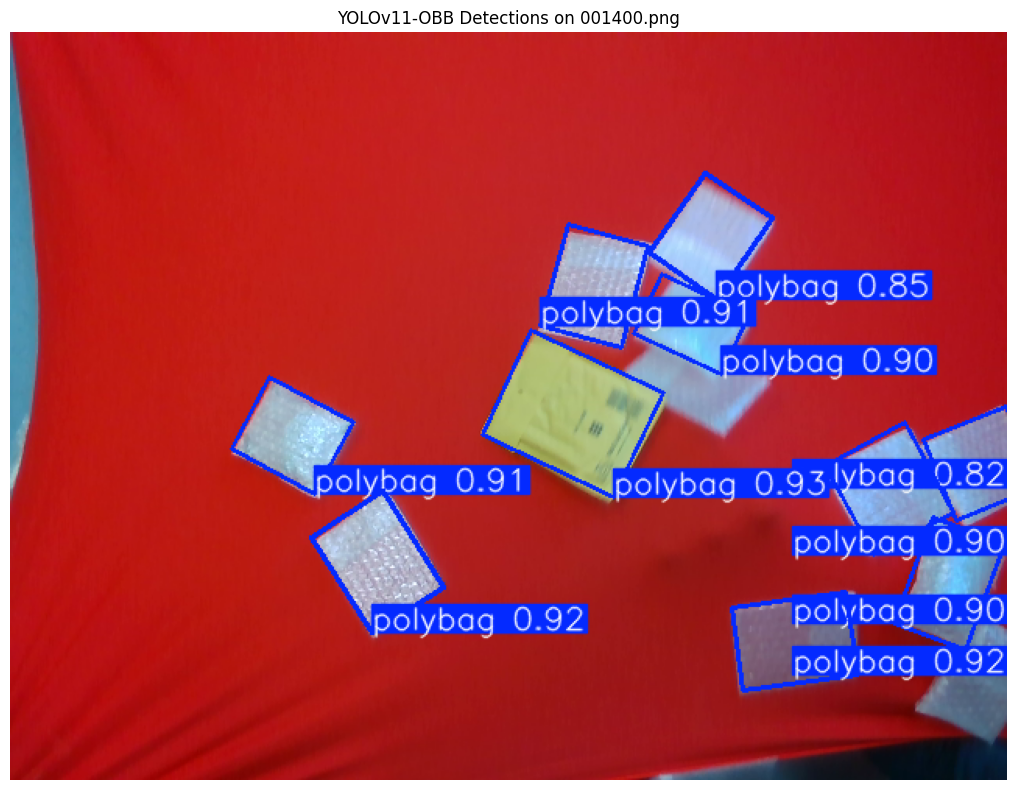

✅ Detected 10 objects


In [17]:
# Load the trained model
model = YOLO(str(BEST_WEIGHTS))

if SAMPLE_IMAGE:
    print(f"🔍 Running inference on: {SAMPLE_IMAGE.name}")
    results = model(str(SAMPLE_IMAGE), verbose=False)
    
    # Visualize with matplotlib
    img_with_boxes = results[0].plot()
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"YOLOv11-OBB Detections on {SAMPLE_IMAGE.name}")
    plt.tight_layout()
    plt.show()
    
    # Print detection stats
    num_detections = len(results[0].obb) if results[0].obb is not None else 0
    print(f"✅ Detected {num_detections} objects")
else:
    print("⚠️ No sample image available")

## Step 4: Generate Reference Masks from JSON Annotations

Convert X-AnyLabeling JSON annotations to binary PNG masks for Dice evaluation.

In [18]:
# Check if JSONs exist
json_files = list(SOURCE_JSONS.glob("*.json"))
print(f"📁 Found {len(json_files)} JSON files in {SOURCE_JSONS}")

if json_files:
    # Use source images directory for dimension detection
    image_dir_for_dims = SOURCE_IMAGES if SOURCE_IMAGES.exists() else None
    
    # Convert JSONs to reference masks
    mask_summary = convert_all_jsons_to_masks(
        json_dir=SOURCE_JSONS,
        output_mask_dir=REFERENCE_MASK_DIR,
        image_dir=image_dir_for_dims,
    )
    
    print(f"\n📊 Conversion Summary:")
    print(f"   Processed: {mask_summary['processed']}")
    print(f"   Created: {mask_summary['created']}")
else:
    print("⚠️ No JSON files found! Cannot create reference masks.")
    print(f"   Expected JSON files in: {SOURCE_JSONS}")

📁 Found 434 JSON files in /home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool/output/jsons
🔄 CONVERTING JSON ANNOTATIONS TO REFERENCE MASKS
  Input JSONs: /home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool/output/jsons
  Output masks: /home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool/dataset_split/reference_masks
  [50/434] 001449.json ✅
  [100/434] 001499.json ✅
  [150/434] 001549.json ✅
  [200/434] 001599.json ✅
  [250/434] 001649.json ✅
  [300/434] 001699.json ✅
  [350/434] 001749.json ✅
  [400/434] 001799.json ✅
  [434/434] 001833.json ✅

🎉 Complete: 434/434 masks created → /home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool/dataset_split/reference_masks

📊 Conversion Summary:
   Processed: 434
   Created: 434


## Step 5: Verify Reference Masks

Visualize the generated masks to ensure they are correct.

📁 Found 434 reference masks in /home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool/dataset_split/reference_masks
📊 Visualizing 5 samples...


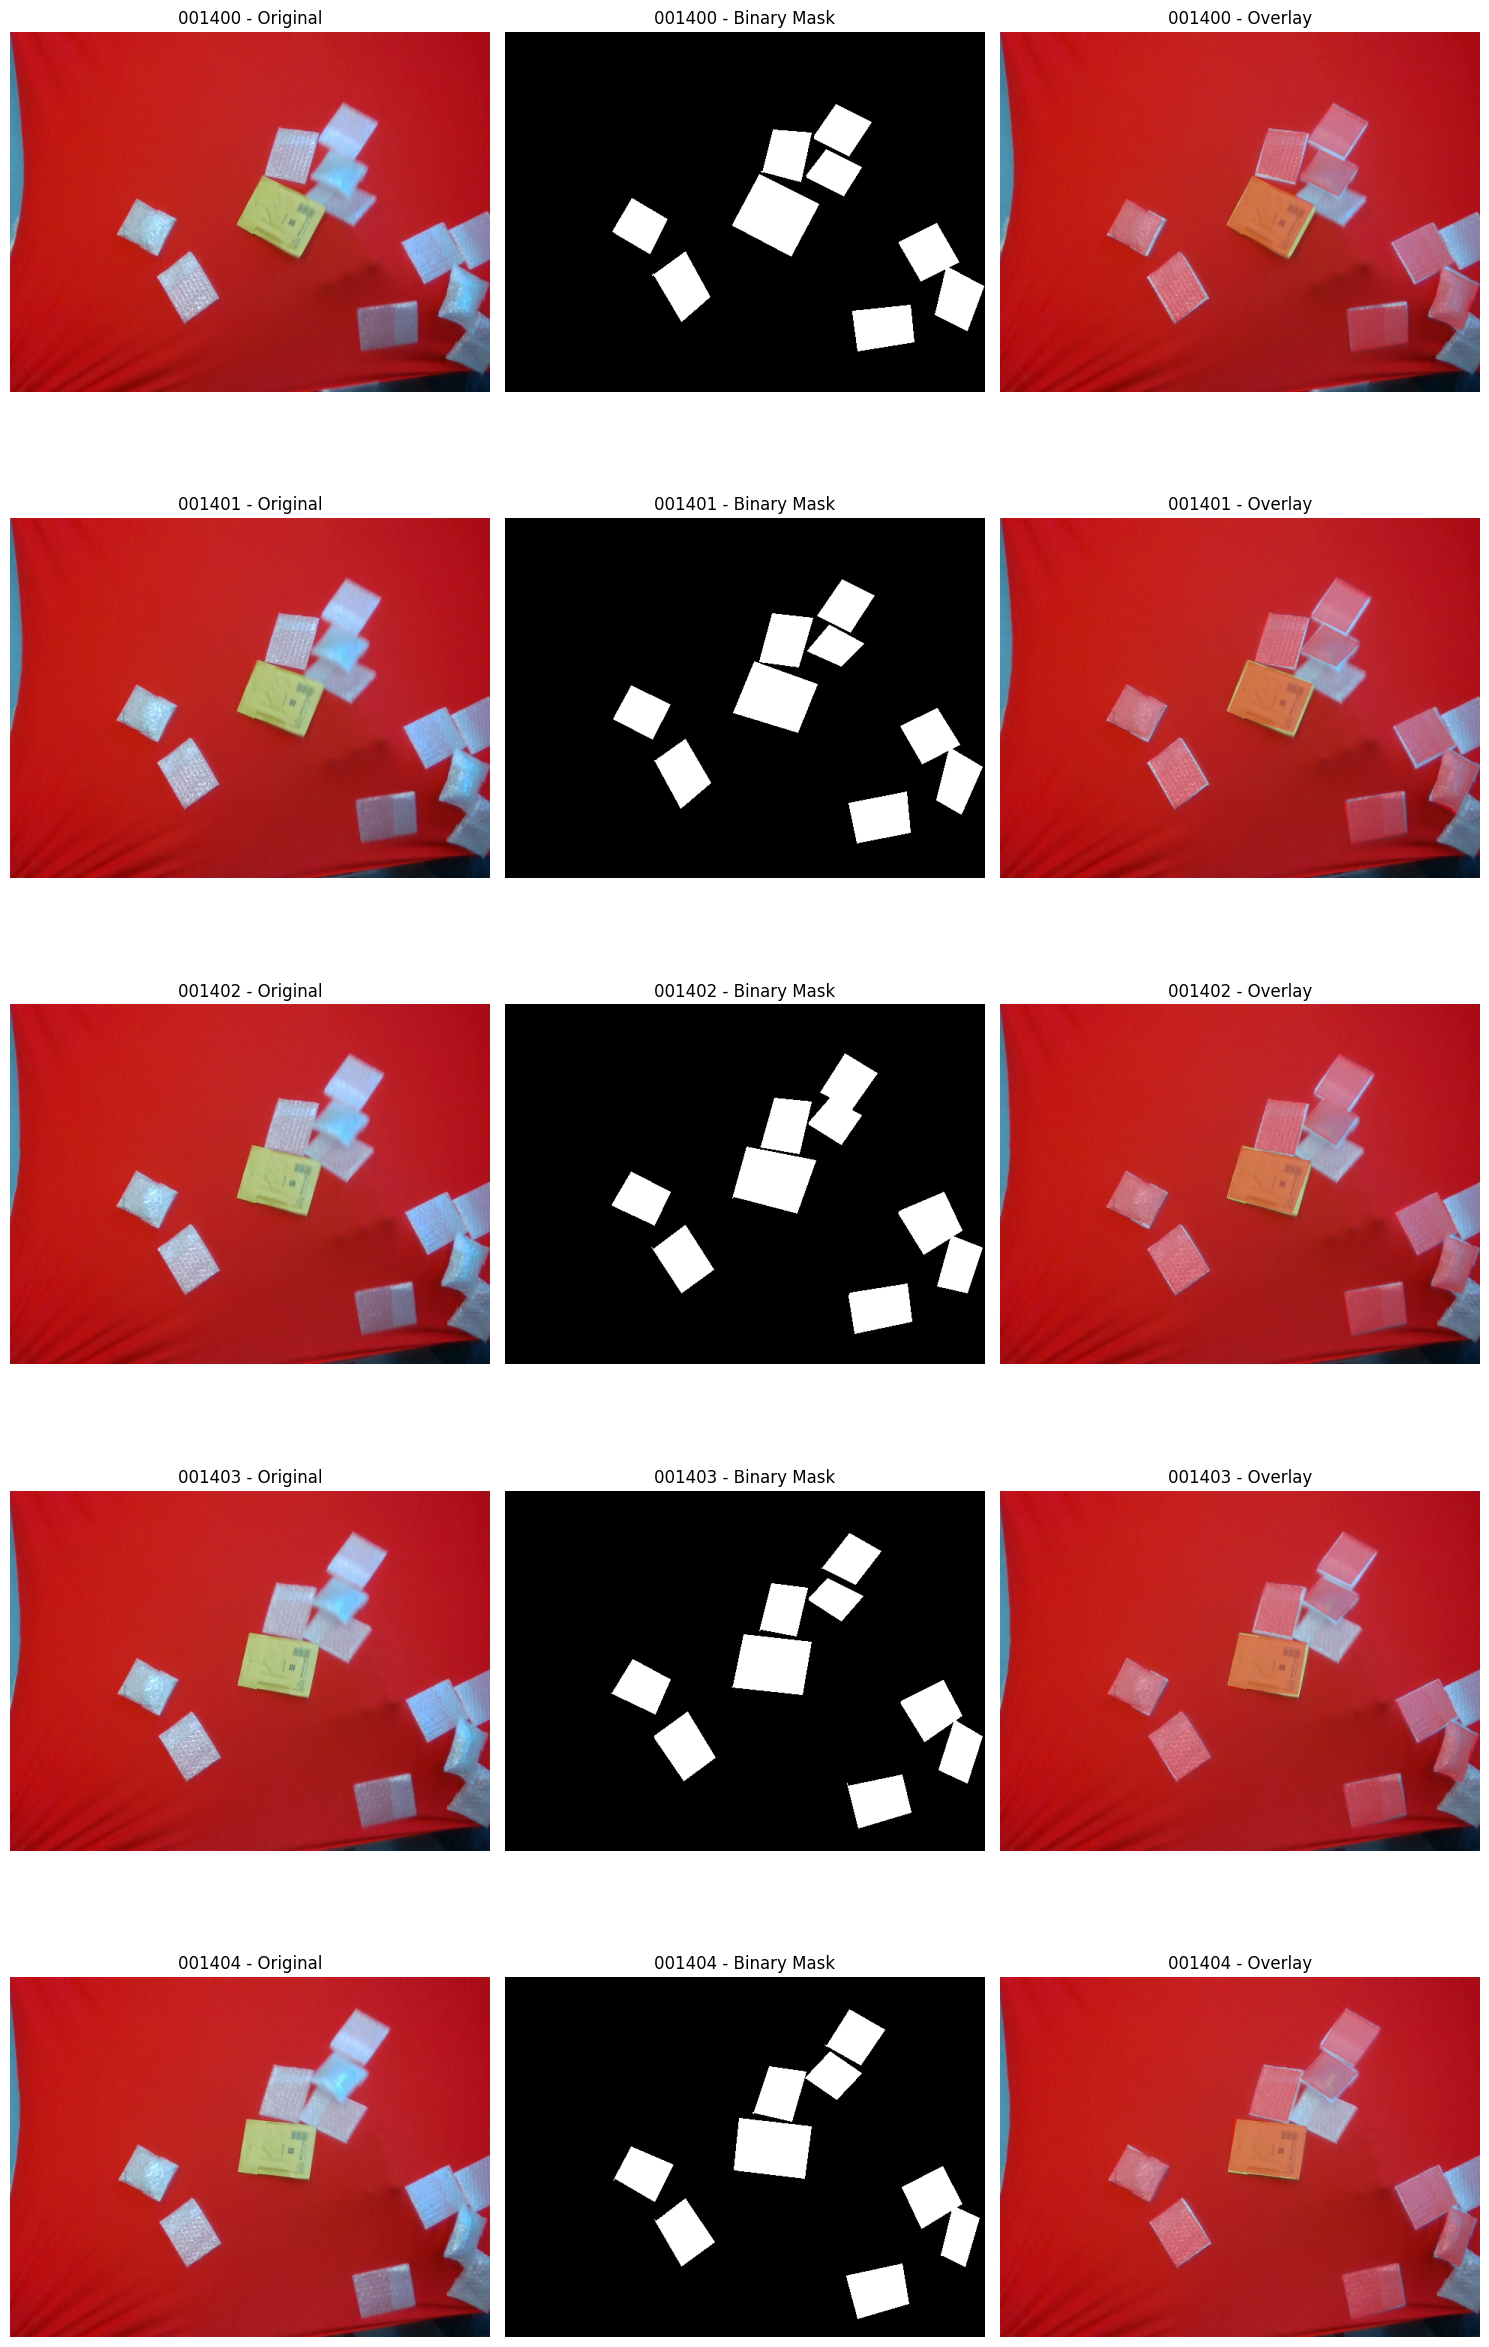

✅ Visualization complete


In [19]:
# Check if reference masks exist
ref_masks = list(REFERENCE_MASK_DIR.glob("*.png"))
print(f"📁 Found {len(ref_masks)} reference masks in {REFERENCE_MASK_DIR}")

if ref_masks:
    # Use source images for visualization (masks match source image names)
    vis_image_dir = SOURCE_IMAGES if SOURCE_IMAGES.exists() else IMAGES_TRAIN
    visualize_masks(
        image_dir=vis_image_dir,
        mask_dir=REFERENCE_MASK_DIR,
        num_samples=5,
    )
else:
    print("⚠️ Cannot visualize - no reference masks found")

## Step 6: Initialize Detector with SAM

Create the YOLOv11 + SAM detector for segmentation.

In [20]:
# Find available SAM checkpoints
available_sam_variants = []
for name, path in SAM_CHECKPOINTS.items():
    variant = SAMVariant(name=name, checkpoint=path)
    available_sam_variants.append(variant)
    print(variant)

# Filter to only existing checkpoints
valid_variants = [v for v in available_sam_variants if v.exists()]
print(f"\n✅ {len(valid_variants)} SAM checkpoints available")

if not valid_variants:
    print("\n⚠️ No SAM checkpoints found! Download one with:")
    print("   yolo download model=sam2.1_b.pt")
    print("   yolo download model=sam2_s.pt")
    SAM_CHECKPOINT = None
else:
    SAM_CHECKPOINT = valid_variants[0].checkpoint
    print(f"\n📦 Using SAM checkpoint: {SAM_CHECKPOINT}")

SAMVariant(sam2.1_b, sam2.1_b.pt) ✅
SAMVariant(sam2_s, sam2_s.pt) ✅
SAMVariant(sam3_b, sam3_b.pt) ❌

✅ 2 SAM checkpoints available

📦 Using SAM checkpoint: /home/xegi09mi/19-01-2026_Database/polybag_dataset_yolo_obb/sam2.1_b.pt


In [21]:
# Initialize the combined detector
if SAM_CHECKPOINT and BEST_WEIGHTS.exists():
    detector = YOLOv11_OBB_SAM_Detector(
        yolo_model_path=BEST_WEIGHTS,
        sam_model_path=SAM_CHECKPOINT,
        device="cuda",
        conf_threshold=0.5,
    )
    print("\n✅ Detector initialized and ready!")
else:
    detector = None
    print("⚠️ Could not initialize detector - missing weights or SAM checkpoint")

Loading YOLO model from /home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool/dataset_split/runs/obb/polybag_yolov11/weights/best.pt...
Loading SAM model from /home/xegi09mi/19-01-2026_Database/polybag_dataset_yolo_obb/sam2.1_b.pt...
✅ Models loaded on cuda

✅ Detector initialized and ready!


## Step 7: Test Detection + Segmentation on Sample Image

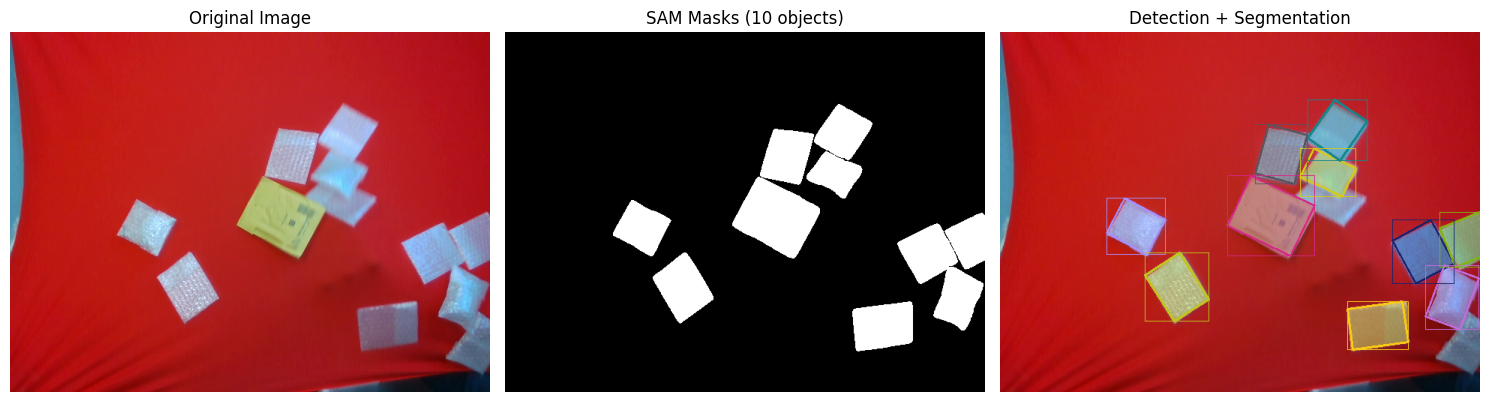

✅ Detected 10 objects


In [22]:
if detector and SAMPLE_IMAGE:
    visualize_detection_results(detector, SAMPLE_IMAGE)
else:
    print("⚠️ Cannot visualize - detector or sample image not available")

## Step 8: Evaluate SAM Variants with Dice Coefficient

Compare different SAM checkpoints and compute Dice scores against reference masks.

In [23]:
# Prepare evaluation dataset
# Use images that have corresponding reference masks
if REFERENCE_MASK_DIR.exists():
    available_masks = {p.stem for p in REFERENCE_MASK_DIR.glob("*.png")}
    eval_images = [img for img in all_images if img.stem in available_masks]
else:
    eval_images = all_images
    available_masks = set()

print(f"📊 Evaluation Dataset:")
print(f"   Total images: {len(all_images)}")
print(f"   Available reference masks: {len(available_masks)}")
print(f"   Images with masks: {len(eval_images)}")

# Limit for faster evaluation (remove or increase for full evaluation)
EVAL_LIMIT = min(50, len(eval_images))  # Evaluate up to 50 images
eval_subset = eval_images[:EVAL_LIMIT]
print(f"   Evaluating: {len(eval_subset)} images")

📊 Evaluation Dataset:
   Total images: 434
   Available reference masks: 434
   Images with masks: 434
   Evaluating: 50 images


In [24]:
# Run evaluation on all available SAM variants
if valid_variants and eval_subset and BEST_WEIGHTS.exists():
    sam_eval_results = evaluate_sam_variants(
        image_paths=eval_subset,
        yolo_model_path=BEST_WEIGHTS,
        sam_variants=valid_variants,
        reference_mask_dir=REFERENCE_MASK_DIR if REFERENCE_MASK_DIR.exists() else None,
        device="cuda",
        conf_threshold=0.5,
        use_obb_corners=False,
    )
    
    # Display results as DataFrame
    results_df = pd.DataFrame(sam_eval_results)
    print("\n" + "=" * 80)
    print("📊 SAM VARIANT COMPARISON RESULTS")
    print("=" * 80)
    print(results_df.to_string(index=False))
    print("=" * 80)
else:
    print("⚠️ Cannot evaluate - missing SAM variants, images, or YOLO weights")
    sam_eval_results = []
    results_df = None


📊 EVALUATING: sam2.1_b
   Checkpoint: /home/xegi09mi/19-01-2026_Database/polybag_dataset_yolo_obb/sam2.1_b.pt
   Images: 50
Loading YOLO model from /home/xegi09mi/19-01-2026_Database/annotated_polyBag_customTool/dataset_split/runs/obb/polybag_yolov11/weights/best.pt...
Loading SAM model from /home/xegi09mi/19-01-2026_Database/polybag_dataset_yolo_obb/sam2.1_b.pt...
✅ Models loaded on cuda
  [  1/50] 001400.png | 0.16s | Dice=0.8989
  [  2/50] 001401.png | 0.10s | Dice=0.8959
  [  3/50] 001403.png | 0.10s | Dice=0.9157
  [  4/50] 001405.png | 0.13s | Dice=0.8698
  [  5/50] 001406.png | 0.13s | Dice=0.8711
  [  6/50] 001407.png | 0.12s | Dice=0.8690
  [  7/50] 001408.png | 0.12s | Dice=0.8607
  [  8/50] 001409.png | 0.11s | Dice=0.8662
  [  9/50] 001410.png | 0.11s | Dice=0.8170
  [ 10/50] 001412.png | 0.11s | Dice=0.9298
  [ 11/50] 001413.png | 0.11s | Dice=0.9271
  [ 12/50] 001415.png | 0.11s | Dice=0.9376
  [ 13/50] 001416.png | 0.11s | Dice=0.9428
  [ 14/50] 001417.png | 0.11s | Dic

## Step 9: Results Summary and Visualization

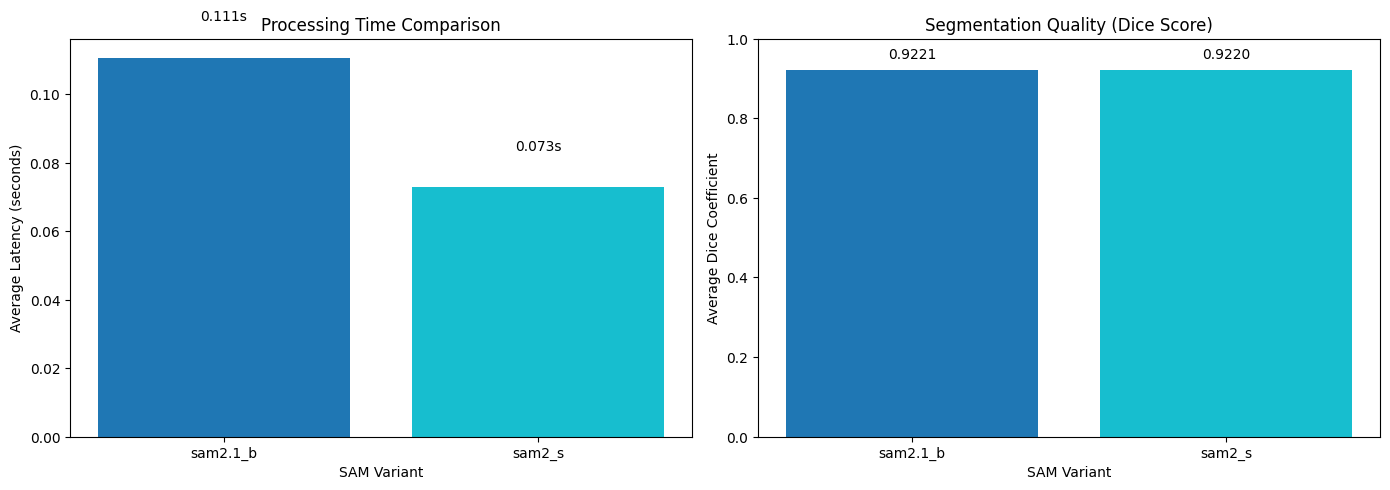


🏆 BEST RESULTS:
   Best Dice Score: sam2.1_b (0.9221)
   Fastest: sam2_s (0.073s)


In [25]:
if results_df is not None and len(results_df) > 0:
    # Plot comparison chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Latency comparison
    variants = results_df['variant'].tolist()
    latencies = results_df['avg_latency_sec'].tolist()
    colors = plt.cm.tab10(np.linspace(0, 1, len(variants)))
    
    axes[0].bar(variants, latencies, color=colors)
    axes[0].set_xlabel('SAM Variant')
    axes[0].set_ylabel('Average Latency (seconds)')
    axes[0].set_title('Processing Time Comparison')
    for i, v in enumerate(latencies):
        if v is not None:
            axes[0].text(i, v + 0.01, f'{v:.3f}s', ha='center', va='bottom')
    
    # Dice comparison
    dice_scores = results_df['avg_dice'].tolist()
    valid_dice = [(v, d) for v, d in zip(variants, dice_scores) if d is not None]
    
    if valid_dice:
        v_names, d_values = zip(*valid_dice)
        axes[1].bar(v_names, d_values, color=colors[:len(v_names)])
        axes[1].set_xlabel('SAM Variant')
        axes[1].set_ylabel('Average Dice Coefficient')
        axes[1].set_title('Segmentation Quality (Dice Score)')
        axes[1].set_ylim(0, 1)
        for i, v in enumerate(d_values):
            axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')
    else:
        axes[1].text(0.5, 0.5, 'No Dice scores available\n(missing reference masks)', 
                    ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
        axes[1].set_title('Segmentation Quality (Dice Score)')
    
    plt.tight_layout()
    plt.show()
    
    # Print best variant
    print("\n" + "=" * 60)
    print("🏆 BEST RESULTS:")
    if valid_dice:
        best_idx = np.argmax(d_values)
        print(f"   Best Dice Score: {v_names[best_idx]} ({d_values[best_idx]:.4f})")
    if latencies and any(l is not None for l in latencies):
        valid_lat = [(v, l) for v, l in zip(variants, latencies) if l is not None]
        fastest_idx = np.argmin([l for _, l in valid_lat])
        print(f"   Fastest: {valid_lat[fastest_idx][0]} ({valid_lat[fastest_idx][1]:.3f}s)")
    print("=" * 60)
else:
    print("⚠️ No results to visualize")

## Optional: Auto-Annotate Dataset with SAM

Generate polygon annotations using the trained YOLO model and SAM.

In [26]:
# Uncomment to run auto-annotation
RUN_AUTO_ANNOTATION = False  # Set to True to run

if RUN_AUTO_ANNOTATION and BEST_WEIGHTS.exists() and SAM_CHECKPOINT:
    annotation_summary = auto_annotate_with_sam(
        yolo_model_path=BEST_WEIGHTS,
        sam_model_path=SAM_CHECKPOINT,
        image_dir=IMAGES_TRAIN,
        output_label_dir=AUTO_LABEL_DIR,
        pattern="*.png",
        device="cuda",
        conf_threshold=0.5,
        use_obb_corners=True,
    )
    print(f"\n📊 Auto-annotation Summary: {annotation_summary}")
else:
    print("⏭️ Auto-annotation skipped (RUN_AUTO_ANNOTATION=False)")

⏭️ Auto-annotation skipped (RUN_AUTO_ANNOTATION=False)


---
## 14. Pixel-Level Segmentation Tracking

IoU-based tracker that assigns persistent `track_id` to each polybag across frames.

**Matching strategies:**
- **Greedy** — sort by similarity, pick best first (fast)
- **Hungarian** — globally optimal assignment via `scipy.optimize.linear_sum_assignment` (more accurate)

**Matching priority:**
1. Pixel-level mask IoU (when masks available from SAM)
2. Bounding-box IoU (fallback)

In [ ]:
# ── Helper functions ──────────────────────────────────────────────────────────

def _frame_index_from_path(p: Path) -> int:
    """Extract numeric frame index from filenames like rgb_frame_000001.png -> 1."""
    m = re.search(r"(\d+)$", p.stem)
    return int(m.group(1)) if m else -1


def _bbox_iou(a: Sequence[float], b: Sequence[float], eps: float = 1e-9) -> float:
    """Axis-aligned IoU between two [x1,y1,x2,y2] boxes."""
    ax1, ay1, ax2, ay2 = map(float, a)
    bx1, by1, bx2, by2 = map(float, b)
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    union = (max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
             + max(0.0, bx2 - bx1) * max(0.0, by2 - by1) - inter)
    return float(inter / (union + eps))


def _mask_iou(a: np.ndarray, b: np.ndarray, eps: float = 1e-9) -> float:
    """Pixel-level IoU between two boolean/uint8 masks."""
    a_bool = a.astype(bool) if a.dtype != bool else a
    b_bool = b.astype(bool) if b.dtype != bool else b
    inter = np.logical_and(a_bool, b_bool).sum()
    union = np.logical_or(a_bool, b_bool).sum()
    return float(inter / (union + eps))


# ── Track data structure ─────────────────────────────────────────────────────

@dataclass
class _Track:
    track_id: int
    cls: int
    last_bbox: List[float]
    last_mask: Optional[np.ndarray]
    last_conf: float
    last_frame_idx: int
    hits: int = 0
    misses: int = 0
    total_misses: int = 0
    created_frame_idx: int = 0
    history: List[Dict] = field(default_factory=list)


# ── SegmentationTracker ──────────────────────────────────────────────────────

class SegmentationTracker:
    """
    Online tracker for the polybag conveyor pipeline.

    Matching priority:
      1. Pixel-level mask IoU  (when masks are available)
      2. Bbox IoU              (fallback)
    Only matches detections to tracks with the same class_id.
    Tracks are dropped after ``max_age`` consecutive misses.
    """

    STRATEGIES = ("greedy", "hungarian")

    def __init__(
        self,
        mask_iou_threshold: float = 0.2,
        bbox_iou_threshold: float = 0.3,
        max_age: int = 10,
        matching_strategy: str = "greedy",
    ) -> None:
        if matching_strategy not in self.STRATEGIES:
            raise ValueError(
                f"matching_strategy must be one of "
                f"{self.STRATEGIES}, got '{matching_strategy}'"
            )
        self.matching_strategy = matching_strategy
        self.mask_iou_thresh = float(mask_iou_threshold)
        self.bbox_iou_thresh = float(bbox_iou_threshold)
        self.max_age = int(max_age)
        self._next_id = 1
        self.active: List[_Track] = []
        self.finished: List[_Track] = []
        # stats
        self._match_ious: List[float] = []
        self._num_matches = 0
        self._num_unmatched = 0
        self._num_dets = 0

    # -- internal helpers --------------------------------------------------
    def _new_track(self, det: Dict, frame_idx: int) -> _Track:
        t = _Track(
            track_id=self._next_id, cls=int(det["class"]),
            last_bbox=list(map(float, det["bbox"])),
            last_mask=det.get("mask"),
            last_conf=float(det.get("confidence", 0.0)),
            last_frame_idx=frame_idx, hits=1,
            created_frame_idx=frame_idx,
        )
        self._next_id += 1
        return t

    def _similarity(self, trk: _Track, det: Dict) -> float:
        """Best available similarity (mask IoU preferred)."""
        m_trk = trk.last_mask
        m_det = det.get("mask")
        if m_trk is not None and m_det is not None:
            try:
                return _mask_iou(m_trk, m_det)
            except Exception:
                pass
        return _bbox_iou(trk.last_bbox, det["bbox"])

    # -- matching strategies ------------------------------------------------
    @staticmethod
    def _greedy_assign(
        sim_matrix: np.ndarray, threshold: float,
    ) -> List[Tuple[int, int, float]]:
        """Greedy: pick highest-similarity pair first, reserve both."""
        candidates: List[Tuple[float, int, int]] = []
        n_trk, n_det = sim_matrix.shape
        for ti in range(n_trk):
            for di in range(n_det):
                s = sim_matrix[ti, di]
                if s >= threshold:
                    candidates.append((s, ti, di))
        candidates.sort(key=lambda x: x[0], reverse=True)
        t_used: set = set()
        d_used: set = set()
        matches: List[Tuple[int, int, float]] = []
        for s, ti, di in candidates:
            if ti in t_used or di in d_used:
                continue
            t_used.add(ti)
            d_used.add(di)
            matches.append((ti, di, s))
        return matches

    @staticmethod
    def _hungarian_assign(
        sim_matrix: np.ndarray, threshold: float,
    ) -> List[Tuple[int, int, float]]:
        """
        Hungarian (Kuhn-Munkres) globally optimal assignment.
        Maximise total similarity via scipy.optimize.linear_sum_assignment
        on a cost matrix = 1 - similarity.
        """
        if sim_matrix.size == 0:
            return []
        cost = 1.0 - sim_matrix
        row_ind, col_ind = linear_sum_assignment(cost)
        matches: List[Tuple[int, int, float]] = []
        for ti, di in zip(row_ind, col_ind):
            s = sim_matrix[ti, di]
            if s >= threshold:
                matches.append((int(ti), int(di), float(s)))
        return matches

    # -- public API --------------------------------------------------------
    def update(self, detections: List[Dict], frame_idx: int) -> List[Dict]:
        """
        Parameters
        ----------
        detections : list of dict
            Each dict must have: bbox [x1,y1,x2,y2], class (int).
            Optionally: confidence, mask (np.ndarray), polygon (list[float]).
        frame_idx : int

        Returns
        -------
        list of per-detection records with assigned ``track_id``.
        """
        self._num_dets += len(detections)

        use_mask = any(d.get("mask") is not None for d in detections) and any(
            t.last_mask is not None for t in self.active
        )
        threshold = self.mask_iou_thresh if use_mask else self.bbox_iou_thresh

        # build similarity matrix
        n_trk = len(self.active)
        n_det = len(detections)
        sim_matrix = np.zeros((n_trk, n_det), dtype=float)
        for ti, trk in enumerate(self.active):
            for di, det in enumerate(detections):
                if trk.cls != int(det["class"]):
                    continue
                sim_matrix[ti, di] = self._similarity(trk, det)

        if self.matching_strategy == "hungarian":
            matches = self._hungarian_assign(sim_matrix, threshold)
        else:
            matches = self._greedy_assign(sim_matrix, threshold)

        t_matched = {ti for ti, _, _ in matches}
        d_matched = {di for _, di, _ in matches}

        det_records: List[Dict] = []

        # apply matched
        for ti, di, sim in matches:
            trk = self.active[ti]
            det = detections[di]
            trk.last_bbox = list(map(float, det["bbox"]))
            trk.last_mask = det.get("mask")
            trk.last_conf = float(det.get("confidence", trk.last_conf))
            trk.last_frame_idx = frame_idx
            trk.hits += 1
            trk.misses = 0
            self._match_ious.append(sim)
            self._num_matches += 1
            rec = {
                "frame_idx": frame_idx, "track_id": trk.track_id,
                "class": int(det["class"]),
                "confidence": float(det.get("confidence", 0.0)),
                "bbox": list(map(float, det["bbox"])),
                "match_iou": float(sim),
                "polygon": det.get("polygon"),
            }
            trk.history.append(rec)
            det_records.append(rec)

        # unmatched tracks -> miss
        for ti, trk in enumerate(self.active):
            if ti not in t_matched:
                trk.misses += 1
                trk.total_misses += 1

        # drop old
        still: List[_Track] = []
        for trk in self.active:
            if trk.misses > self.max_age:
                self.finished.append(trk)
            else:
                still.append(trk)
        self.active = still

        # create new tracks for unmatched detections
        for di, det in enumerate(detections):
            if di in d_matched:
                continue
            self._num_unmatched += 1
            trk = self._new_track(det, frame_idx)
            rec = {
                "frame_idx": frame_idx, "track_id": trk.track_id,
                "class": int(det["class"]),
                "confidence": float(det.get("confidence", 0.0)),
                "bbox": list(map(float, det["bbox"])),
                "match_iou": None,
                "polygon": det.get("polygon"),
            }
            trk.history.append(rec)
            self.active.append(trk)
            det_records.append(rec)

        return det_records

    def finalize(self) -> None:
        self.finished.extend(self.active)
        self.active = []

    def metrics(self) -> Dict:
        tracks = self.finished + self.active
        lengths = [len(t.history) for t in tracks]
        return {
            "num_detections_total": int(self._num_dets),
            "num_matches_total": int(self._num_matches),
            "num_new_tracks_created": int(self._num_unmatched),
            "unmatched_rate": round(self._num_unmatched / self._num_dets, 4) if self._num_dets else None,
            "num_tracks": int(len(tracks)),
            "track_length_mean": round(float(np.mean(lengths)), 2) if lengths else None,
            "track_length_median": float(np.median(lengths)) if lengths else None,
            "track_length_min": int(np.min(lengths)) if lengths else None,
            "track_length_max": int(np.max(lengths)) if lengths else None,
            "match_iou_mean": round(float(np.mean(self._match_ious)), 4) if self._match_ious else None,
            "match_iou_median": round(float(np.median(self._match_ious)), 4) if self._match_ious else None,
            "matching_strategy": self.matching_strategy,
            "per_track": [
                {
                    "track_id": t.track_id, "class": t.cls,
                    "first_frame": t.created_frame_idx,
                    "last_frame": t.last_frame_idx,
                    "hits": t.hits, "total_misses": t.total_misses,
                    "length": len(t.history),
                }
                for t in tracks
            ],
        }

print("✅ _Track, SegmentationTracker, and IoU helpers defined")

In [ ]:
def run_tracking_pipeline(
    detector: YOLOv11_OBB_SAM_Detector,
    image_dir: Path,
    output_label_dir: Path,
    tracks_csv_path: Path,
    metrics_json_path: Path,
    pattern: str = "*.png",
    use_obb_corners: bool = False,
    mask_iou_threshold: float = 0.2,
    bbox_iou_threshold: float = 0.3,
    max_age: int = 10,
    matching_strategy: str = "greedy",
    save_labels: bool = True,
) -> Dict:
    """
    Full pipeline: detect → segment → track (mask IoU).

    Parameters
    ----------
    detector : YOLOv11_OBB_SAM_Detector
        Already-initialised detector instance.
    matching_strategy : "greedy" or "hungarian"

    Returns dict with tracking metrics.
    """
    image_paths = sorted(image_dir.glob(pattern), key=_frame_index_from_path)
    total = len(image_paths)

    output_label_dir.mkdir(parents=True, exist_ok=True)
    tracks_csv_path.parent.mkdir(parents=True, exist_ok=True)
    metrics_json_path.parent.mkdir(parents=True, exist_ok=True)

    tracker = SegmentationTracker(
        mask_iou_threshold=mask_iou_threshold,
        bbox_iou_threshold=bbox_iou_threshold,
        max_age=max_age,
        matching_strategy=matching_strategy,
    )

    processed = 0
    labeled = 0
    frames_with_dets = 0

    csv_cols = [
        "frame_idx", "image_name", "track_id", "class_id",
        "confidence", "bbox_x1", "bbox_y1", "bbox_x2", "bbox_y2",
        "match_iou", "polygon_norm",
    ]

    with tracks_csv_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=csv_cols)
        writer.writeheader()

        for frame_idx, image_path in enumerate(image_paths):
            processed += 1
            image = cv2.imread(str(image_path))
            if image is None:
                print(f"[{processed}/{total}] {image_path.name} unreadable", flush=True)
                continue

            results = detector.process_image(image, use_obb_corners=use_obb_corners)
            obb_info = results["obb_info"]
            masks = results["segmentations"]
            n = min(len(obb_info), len(masks))

            detections: List[Dict] = []
            for i in range(n):
                obb = obb_info[i]
                mask_raw = masks[i]
                mask_2d = detector._ensure_2d(mask_raw)
                polygon = detector.mask_to_polygon(mask_raw)
                detections.append({
                    "bbox": obb["bbox"],
                    "class": int(obb["class"]),
                    "confidence": float(obb.get("confidence", 0.0)),
                    "mask": mask_2d,
                    "polygon": polygon if polygon else None,
                })

            if detections:
                frames_with_dets += 1

            det_records = tracker.update(detections, frame_idx)

            # write YOLO labels
            wrote_any = False
            if save_labels:
                label_path = output_label_dir / f"{image_path.stem}.txt"
                with label_path.open("w", encoding="utf-8") as lf:
                    for rec in det_records:
                        poly = rec.get("polygon")
                        if not poly:
                            continue
                        lf.write(f"{int(rec['class'])} " + " ".join(f"{c:.6f}" for c in poly) + "\n")
                        wrote_any = True
                if not wrote_any:
                    label_path.unlink(missing_ok=True)
            if wrote_any:
                labeled += 1

            # write CSV rows
            for rec in det_records:
                bb = rec["bbox"]
                poly = rec.get("polygon")
                writer.writerow({
                    "frame_idx": int(rec["frame_idx"]),
                    "image_name": image_path.name,
                    "track_id": int(rec["track_id"]),
                    "class_id": int(rec["class"]),
                    "confidence": float(rec.get("confidence", 0.0)),
                    "bbox_x1": float(bb[0]), "bbox_y1": float(bb[1]),
                    "bbox_x2": float(bb[2]), "bbox_y2": float(bb[3]),
                    "match_iou": "" if rec.get("match_iou") is None else f"{rec['match_iou']:.4f}",
                    "polygon_norm": "" if not poly else " ".join(f"{c:.6f}" for c in poly),
                })

            if processed % 50 == 0 or processed == total:
                print(
                    f"[{processed}/{total}] {image_path.name}  dets={len(detections)}  "
                    f"active_tracks={len(tracker.active)}",
                    flush=True,
                )

    tracker.finalize()
    m = tracker.metrics()
    m["num_frames_total"] = total
    m["num_frames_processed"] = processed
    m["num_frames_with_dets"] = frames_with_dets
    m["labels_written"] = labeled
    m["tracks_csv"] = str(tracks_csv_path)

    with metrics_json_path.open("w", encoding="utf-8") as f:
        json.dump(m, f, indent=2)
    print(f"\n✅ Tracking done  ->  {tracks_csv_path}")
    print(f"   Metrics saved  ->  {metrics_json_path}")
    return m

print("✅ run_tracking_pipeline function defined")

## Step 10: Run Pixel-Level Tracking

Run YOLOv11-OBB → SAM → **mask-IoU tracker** across all frames.
Each polybag gets a persistent `track_id` so we can follow its journey on the conveyor.

**Outputs:**
- `tracks/tracks.csv` — per-detection per-frame records with `track_id`
- `tracks/metrics.json` — track statistics (lengths, match quality, …)
- (optional) YOLO polygon labels in `labels/auto_tracked/`

In [ ]:
# ── Tracking output paths ─────────────────────────────────────────────────────
TRACKS_DIR = DATA_ROOT / "tracks"
TRACKS_CSV = TRACKS_DIR / "tracks.csv"
METRICS_JSON = TRACKS_DIR / "metrics.json"
AUTO_TRACK_LABELS = DATA_ROOT / "labels" / "auto_tracked"

TRACKS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Tracks output  : {TRACKS_DIR}")
print(f"Tracked labels : {AUTO_TRACK_LABELS}")

# ── Run full pipeline: Detect + Segment + Track ──────────────────────────────
IMAGE_DIR_FOR_TRACKING = DATA_ROOT / "images" / "train"  # or combine train+val

if detector is not None:
    tracking_metrics = run_tracking_pipeline(
        detector=detector,
        image_dir=IMAGE_DIR_FOR_TRACKING,
        output_label_dir=AUTO_TRACK_LABELS,
        tracks_csv_path=TRACKS_CSV,
        metrics_json_path=METRICS_JSON,
        pattern="*.png",
        use_obb_corners=True,
        mask_iou_threshold=0.2,   # pixel-level mask overlap threshold
        bbox_iou_threshold=0.3,   # fallback bbox IoU threshold
        max_age=10,               # drop track after 10 consecutive misses
        matching_strategy="greedy",
        save_labels=True,
    )

    print(f"\nTotal tracks found: {tracking_metrics['num_tracks']}")
    print(f"Total detections:   {tracking_metrics['num_detections_total']}")
    print(f"Frames with dets:   {tracking_metrics['num_frames_with_dets']}")
else:
    print("⚠️ Detector not initialised — run Step 6 first")

In [ ]:
# ── Display Tracking Metrics ──────────────────────────────────────────────────
with open(METRICS_JSON, "r") as f:
    metrics = json.load(f)

summary_keys = [
    "num_frames_total", "num_frames_processed", "num_frames_with_dets",
    "num_detections_total", "num_matches_total", "num_new_tracks_created",
    "unmatched_rate", "num_tracks",
    "track_length_mean", "track_length_median", "track_length_min", "track_length_max",
    "match_iou_mean", "match_iou_median",
]
print("=" * 60)
print("  TRACKING METRICS SUMMARY")
print("=" * 60)
for k in summary_keys:
    v = metrics.get(k)
    print(f"  {k:35s}:  {v}")
print("=" * 60)

# Per-track table
per_track = metrics.get("per_track", [])
if per_track:
    track_df = pd.DataFrame(per_track)
    track_df = track_df.sort_values("length", ascending=False)
    print(f"\nPer-Track Details ({len(track_df)} tracks):")
    print(track_df.to_string(index=False))

In [ ]:
# ── Track Length Distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lengths = track_df["length"].values

# Histogram of track lengths
axes[0].hist(lengths, bins=max(10, len(set(lengths))), edgecolor="black", alpha=0.75, color="steelblue")
axes[0].set_xlabel("Track Length (frames)")
axes[0].set_ylabel("Count")
axes[0].set_title("Track Length Distribution")
axes[0].axvline(np.mean(lengths), color="red", ls="--", label=f"mean={np.mean(lengths):.1f}")
axes[0].axvline(np.median(lengths), color="orange", ls="--", label=f"median={np.median(lengths):.1f}")
axes[0].legend()

# Track timeline (Gantt-like)
for _, row in track_df.iterrows():
    axes[1].barh(
        y=f"T{row['track_id']}",
        width=row["length"],
        left=row["first_frame"],
        height=0.6,
        color=plt.cm.tab20(int(row["track_id"]) % 20),
        edgecolor="black", linewidth=0.3,
    )
axes[1].set_xlabel("Frame Index")
axes[1].set_title("Track Lifetimes (Gantt)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# ── Visualise Tracked Polybag Journeys (bbox centre trajectories) ─────────────
tracks_df = pd.read_csv(TRACKS_CSV)

# Compute bbox centre
tracks_df["cx"] = (tracks_df["bbox_x1"] + tracks_df["bbox_x2"]) / 2
tracks_df["cy"] = (tracks_df["bbox_y1"] + tracks_df["bbox_y2"]) / 2

# Load a sample frame as background
bg_path = sorted(IMAGE_DIR_FOR_TRACKING.glob("*.png"), key=_frame_index_from_path)[0]
bg = cv2.cvtColor(cv2.imread(str(bg_path)), cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(bg, alpha=0.4)

unique_ids = tracks_df["track_id"].unique()
cmap = plt.cm.get_cmap("tab20", len(unique_ids))

for idx, tid in enumerate(unique_ids):
    sub = tracks_df[tracks_df["track_id"] == tid].sort_values("frame_idx")
    color = cmap(idx % cmap.N)
    ax.plot(sub["cx"], sub["cy"], "-o", markersize=3, linewidth=1.5, color=color, label=f"T{tid}")
    # Start marker
    ax.scatter(sub["cx"].iloc[0], sub["cy"].iloc[0], marker="s", s=60, color=color, edgecolors="black", zorder=5)
    # End marker
    ax.scatter(sub["cx"].iloc[-1], sub["cy"].iloc[-1], marker="X", s=80, color=color, edgecolors="black", zorder=5)

ax.set_title(f"Polybag Trajectories ({len(unique_ids)} tracks)  square=start  X=end")
ax.set_xlabel("x (px)")
ax.set_ylabel("y (px)")
if len(unique_ids) <= 20:
    ax.legend(loc="upper right", fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

In [ ]:
# ── Visualise segmentation masks with track IDs on sample frames ──────────────
all_frames = sorted(IMAGE_DIR_FOR_TRACKING.glob("*.png"), key=_frame_index_from_path)
sample_indices = np.linspace(0, len(all_frames) - 1, 4, dtype=int)
sample_frames = [all_frames[i] for i in sample_indices]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, img_path in zip(axes, sample_frames):
    image = cv2.imread(str(img_path))
    frame_name = img_path.name
    frame_rows = tracks_df[tracks_df["image_name"] == frame_name]

    results = detector.process_image(image, use_obb_corners=True)
    vis = detector.visualize_results(results, show_boxes=False, show_masks=True, show_obb=True)
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

    # Overlay track IDs
    for _, row in frame_rows.iterrows():
        cx, cy = int(row["cx"]), int(row["cy"])
        tid = int(row["track_id"])
        cv2.putText(vis_rgb, f"T{tid}", (cx - 10, cy - 10),
                     cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)

    ax.imshow(vis_rgb)
    ax.set_title(f"{img_path.stem}  ({len(frame_rows)} dets)")
    ax.axis("off")

plt.suptitle("Segmentation + Track IDs on Sample Frames", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ── Per-frame detection & active-track counts (time series) ───────────────────
frame_stats = tracks_df.groupby("frame_idx").agg(
    detections=("track_id", "count"),
    unique_tracks=("track_id", "nunique"),
).reset_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(frame_stats["frame_idx"], frame_stats["detections"], label="Detections", color="steelblue")
ax.plot(frame_stats["frame_idx"], frame_stats["unique_tracks"], label="Active tracks", color="coral", ls="--")
ax.set_xlabel("Frame index")
ax.set_ylabel("Count")
ax.set_title("Detections and Active Tracks per Frame")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── Match IoU distribution (how well the tracker matches across frames) ───────
match_ious = tracks_df["match_iou"].dropna().astype(float)

if len(match_ious) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(match_ious, bins=50, edgecolor="black", alpha=0.75, color="seagreen")
    ax.axvline(match_ious.mean(), color="red", ls="--", label=f"mean={match_ious.mean():.3f}")
    ax.axvline(match_ious.median(), color="orange", ls="--", label=f"median={match_ious.median():.3f}")
    ax.set_xlabel("Match IoU (mask-level)")
    ax.set_ylabel("Count")
    ax.set_title("Tracker Match Quality (higher = better continuity)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No match IoU data available (all detections were new tracks).")

---
## 15. MOTS Ground-Truth Evaluation

Compute standard Multi-Object Tracking and Segmentation metrics by comparing
our tracker output (`tracks.csv`) against ground-truth annotations from the
custom annotation tool (`annotations.json`).

**Ground-truth format** (from custom tool):
```json
{"001400": [{"track_id":1001, "class":"polybag", "class_id":1, "polygon":[[x,y],...]},...], ...}
```

**Metrics computed:**
| Metric | Description |
|--------|-------------|
| **MOTA** | Multi-Object Tracking Accuracy (1 - (FN + FP + IDsw) / GT) |
| **MOTP** | Multi-Object Tracking Precision (mean IoU of matched pairs) |
| **IDF1** | ID F1 score — harmonic mean of ID precision & recall |
| **IDsw** | Total identity switches |
| **MT** | Mostly Tracked targets (>80% of lifespan tracked) |
| **ML** | Mostly Lost targets (<20% of lifespan tracked) |

In [ ]:
def load_gt_annotations(
    annotations_path: Path,
    image_dir: Path,
    image_width: int = 640,
    image_height: int = 480,
) -> Dict[str, List[Dict]]:
    """
    Load ground-truth annotations and rasterise polygon masks.

    Returns
    -------
    Dict mapping frame_key ("001400") -> list of dicts with keys:
        track_id, class_id, polygon, mask (H x W bool np.ndarray)
    """
    with open(annotations_path, "r") as f:
        raw = json.load(f)

    gt_frames: Dict[str, List[Dict]] = {}
    for frame_key, objects in raw.items():
        entries = []
        # Try to get image dimensions from the corresponding image
        h, w = image_height, image_width
        for ext in (".png", ".jpg", ".jpeg"):
            img_path = image_dir / f"rgb_frame_{frame_key}{ext}"
            if img_path.exists():
                img = cv2.imread(str(img_path))
                if img is not None:
                    h, w = img.shape[:2]
                break

        for obj in objects:
            poly_pts = np.array(obj["polygon"], dtype=np.int32)
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillPoly(mask, [poly_pts], 1)
            entries.append({
                "track_id": int(obj["track_id"]),
                "class_id": int(obj.get("class_id", 0)),
                "polygon": obj["polygon"],
                "mask": mask.astype(bool),
            })
        gt_frames[frame_key] = entries
    return gt_frames


def compute_mots_metrics(
    gt_frames: Dict[str, List[Dict]],
    pred_csv: Path,
    image_dir: Path,
    iou_threshold: float = 0.5,
) -> Dict:
    """
    Compute MOTA, MOTP, IDF1, IDsw from GT annotations vs tracker CSV.

    The tracker CSV has columns:
        frame_idx, image_name, track_id, class_id, bbox_x1..y2, ...

    GT frames are keyed by frame number string ("001400").
    We match GT frames to prediction frames by extracting the frame number
    from image_name (e.g. "rgb_frame_001400.png" -> "001400").
    """
    # Load predictions, group by image
    pred_df = pd.read_csv(pred_csv)
    pred_by_image: Dict[str, pd.DataFrame] = {}
    for name, grp in pred_df.groupby("image_name"):
        pred_by_image[name] = grp

    # Build map: frame_key -> image_name
    frame_to_image: Dict[str, str] = {}
    for img_path in sorted(image_dir.glob("*.png")):
        m = re.search(r"(\d{6})(?:\.\w+)?$", img_path.stem)
        if m:
            frame_to_image[m.group(1)] = img_path.name

    total_gt = 0
    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_idsw = 0
    total_iou_sum = 0.0  # sum of IoUs for matched pairs (for MOTP)

    # For IDF1: track GT-to-pred ID mapping
    gt_track_frames: Dict[int, int] = {}   # gt_track_id -> total frames
    pred_track_frames: Dict[int, int] = {}  # pred_track_id -> total frames
    id_correct: Dict[Tuple[int, int], int] = {}  # (gt_id, pred_id) -> correct frames

    # For IDsw: track last assigned pred ID per GT track
    last_pred_id: Dict[int, int] = {}

    # For MT/ML
    gt_track_total: Dict[int, int] = {}
    gt_track_found: Dict[int, int] = {}

    evaluated_frames = 0

    for frame_key in sorted(gt_frames.keys()):
        gt_objects = gt_frames[frame_key]
        image_name = frame_to_image.get(frame_key)
        if image_name is None:
            continue

        evaluated_frames += 1
        pred_rows = pred_by_image.get(image_name, pd.DataFrame())

        n_gt = len(gt_objects)
        n_pred = len(pred_rows)
        total_gt += n_gt

        # count GT tracks for MT/ML
        for g in gt_objects:
            gid = g["track_id"]
            gt_track_total[gid] = gt_track_total.get(gid, 0) + 1

        if n_gt == 0 and n_pred == 0:
            continue

        if n_gt == 0:
            total_fp += n_pred
            for _, pr in pred_rows.iterrows():
                pid = int(pr["track_id"])
                pred_track_frames[pid] = pred_track_frames.get(pid, 0) + 1
            continue

        if n_pred == 0:
            total_fn += n_gt
            for g in gt_objects:
                gid = g["track_id"]
                gt_track_frames[gid] = gt_track_frames.get(gid, 0) + 1
            continue

        # Build IoU matrix (GT x Pred) using bbox IoU
        # (We don't have pred masks in CSV, so use bbox-based matching)
        iou_matrix = np.zeros((n_gt, n_pred), dtype=float)
        pred_list = list(pred_rows.itertuples(index=False))
        for gi, g_obj in enumerate(gt_objects):
            g_mask = g_obj["mask"]
            # Compute GT bbox from mask
            ys, xs = np.where(g_mask)
            if len(xs) == 0:
                continue
            g_bbox = [float(xs.min()), float(ys.min()), float(xs.max()), float(ys.max())]

            for pi, p_row in enumerate(pred_list):
                p_bbox = [float(p_row.bbox_x1), float(p_row.bbox_y1),
                          float(p_row.bbox_x2), float(p_row.bbox_y2)]
                iou_matrix[gi, pi] = _bbox_iou(g_bbox, p_bbox)

        # Hungarian matching
        cost = 1.0 - iou_matrix
        row_ind, col_ind = linear_sum_assignment(cost)

        matched_gt = set()
        matched_pred = set()

        for gi, pi in zip(row_ind, col_ind):
            iou_val = iou_matrix[gi, pi]
            if iou_val >= iou_threshold:
                matched_gt.add(gi)
                matched_pred.add(pi)
                total_tp += 1
                total_iou_sum += iou_val

                gt_id = gt_objects[gi]["track_id"]
                pred_id = int(pred_list[pi].track_id)

                # IDF1 bookkeeping
                gt_track_frames[gt_id] = gt_track_frames.get(gt_id, 0) + 1
                pred_track_frames[pred_id] = pred_track_frames.get(pred_id, 0) + 1
                key = (gt_id, pred_id)
                id_correct[key] = id_correct.get(key, 0) + 1

                # IDsw detection
                if gt_id in last_pred_id and last_pred_id[gt_id] != pred_id:
                    total_idsw += 1
                last_pred_id[gt_id] = pred_id

                # MT/ML
                gt_track_found[gt_id] = gt_track_found.get(gt_id, 0) + 1

        fn_this = n_gt - len(matched_gt)
        fp_this = n_pred - len(matched_pred)
        total_fn += fn_this
        total_fp += fp_this

        # Count unmatched pred tracks for IDF1
        for pi, p_row in enumerate(pred_list):
            if pi not in matched_pred:
                pid = int(p_row.track_id)
                pred_track_frames[pid] = pred_track_frames.get(pid, 0) + 1
        # Count unmatched GT tracks
        for gi, g_obj in enumerate(gt_objects):
            if gi not in matched_gt:
                gid = g_obj["track_id"]
                gt_track_frames[gid] = gt_track_frames.get(gid, 0) + 1

    # ── Compute final metrics ─────────────────────────────────────────────
    mota = 1.0 - (total_fn + total_fp + total_idsw) / max(total_gt, 1)
    motp = total_iou_sum / max(total_tp, 1)

    # IDF1: find best GT<->pred ID mapping (greedy majority)
    # For each GT id, find the pred id with most co-occurrences
    gt_to_best_pred: Dict[int, int] = {}
    for (gid, pid), cnt in id_correct.items():
        if gid not in gt_to_best_pred or cnt > id_correct.get((gid, gt_to_best_pred[gid]), 0):
            gt_to_best_pred[gid] = pid

    idtp = sum(id_correct.get((gid, pid), 0) for gid, pid in gt_to_best_pred.items())
    idfn = sum(gt_track_frames.get(gid, 0) for gid in gt_track_total) - idtp
    idfp = sum(pred_track_frames.values()) - idtp
    idf1 = 2 * idtp / max(2 * idtp + idfn + idfp, 1)

    # MT / ML
    mt = sum(1 for gid, total in gt_track_total.items()
             if gt_track_found.get(gid, 0) / max(total, 1) > 0.8)
    ml = sum(1 for gid, total in gt_track_total.items()
             if gt_track_found.get(gid, 0) / max(total, 1) < 0.2)
    pt = len(gt_track_total) - mt - ml  # partially tracked

    return {
        "evaluated_frames": evaluated_frames,
        "total_gt": total_gt,
        "TP": total_tp,
        "FP": total_fp,
        "FN": total_fn,
        "IDsw": total_idsw,
        "MOTA": round(mota, 4),
        "MOTP": round(motp, 4),
        "IDF1": round(idf1, 4),
        "MT": mt,
        "PT": pt,
        "ML": ml,
        "Recall": round(total_tp / max(total_gt, 1), 4),
        "Precision": round(total_tp / max(total_tp + total_fp, 1), 4),
        "iou_threshold": iou_threshold,
    }

print("✅ MOTS evaluation functions defined")

## Step 11: Run MOTS Evaluation against Ground Truth

Compare our tracker predictions with ground-truth annotations from `annotations.json`.
Adjust `GT_ANNOTATIONS_PATH` below to point to your custom-tool annotations file.

In [ ]:
# ── MOTS Evaluation ──────────────────────────────────────────────────────────
# Path to custom-tool annotations with ground-truth track IDs
GT_ANNOTATIONS_PATH = SOURCE_ROOT / "annotations.json"

if GT_ANNOTATIONS_PATH.exists() and TRACKS_CSV.exists():
    print(f"📁 Loading GT annotations from: {GT_ANNOTATIONS_PATH}")
    gt_frames = load_gt_annotations(
        annotations_path=GT_ANNOTATIONS_PATH,
        image_dir=SOURCE_IMAGES,
    )
    print(f"   GT frames loaded: {len(gt_frames)}")
    print(f"   Frame range: {min(gt_frames.keys())} - {max(gt_frames.keys())}")
    gt_track_ids = {obj['track_id'] for objs in gt_frames.values() for obj in objs}
    print(f"   Unique GT track IDs: {sorted(gt_track_ids)}")

    # Run evaluation
    mots_results = compute_mots_metrics(
        gt_frames=gt_frames,
        pred_csv=TRACKS_CSV,
        image_dir=IMAGE_DIR_FOR_TRACKING,
        iou_threshold=0.5,
    )

    # Display results
    print("\n" + "=" * 60)
    print("  MOTS EVALUATION RESULTS")
    print("=" * 60)
    for k, v in mots_results.items():
        print(f"  {k:25s}:  {v}")
    print("=" * 60)

    # Summary interpretation
    print(f"\n📊 Interpretation:")
    print(f"   MOTA={mots_results['MOTA']:.2%}  (>50% good, >80% excellent)")
    print(f"   MOTP={mots_results['MOTP']:.2%}  (mean IoU of matches; >70% = precise)")
    print(f"   IDF1={mots_results['IDF1']:.2%}  (identity preservation; >50% good)")
    print(f"   IDsw={mots_results['IDsw']}      (lower is better)")
    print(f"   MT={mots_results['MT']}/{mots_results['MT']+mots_results['PT']+mots_results['ML']} mostly tracked")
    print(f"   ML={mots_results['ML']}/{mots_results['MT']+mots_results['PT']+mots_results['ML']} mostly lost")
else:
    mots_results = None
    if not GT_ANNOTATIONS_PATH.exists():
        print(f"⚠️ GT annotations not found: {GT_ANNOTATIONS_PATH}")
    if not TRACKS_CSV.exists():
        print(f"⚠️ Tracking CSV not found — run Step 10 first")

In [ ]:
# ── Greedy vs Hungarian MOTS Comparison ──────────────────────────────────────
# Re-run tracking with Hungarian strategy, then compare both
RUN_STRATEGY_COMPARISON = False  # Set to True to run (processes all frames twice)

if RUN_STRATEGY_COMPARISON and detector is not None and GT_ANNOTATIONS_PATH.exists():
    comparison_results = []

    for strategy in ("greedy", "hungarian"):
        strat_csv = TRACKS_DIR / f"tracks_{strategy}.csv"
        strat_json = TRACKS_DIR / f"metrics_{strategy}.json"
        strat_labels = DATA_ROOT / "labels" / f"auto_tracked_{strategy}"

        print(f"\n{'='*60}")
        print(f"  Running {strategy.upper()} strategy...")
        print(f"{'='*60}")

        trk_metrics = run_tracking_pipeline(
            detector=detector,
            image_dir=IMAGE_DIR_FOR_TRACKING,
            output_label_dir=strat_labels,
            tracks_csv_path=strat_csv,
            metrics_json_path=strat_json,
            pattern="*.png",
            use_obb_corners=True,
            mask_iou_threshold=0.2,
            bbox_iou_threshold=0.3,
            max_age=10,
            matching_strategy=strategy,
            save_labels=False,
        )

        mots = compute_mots_metrics(
            gt_frames=gt_frames,
            pred_csv=strat_csv,
            image_dir=IMAGE_DIR_FOR_TRACKING,
            iou_threshold=0.5,
        )
        mots["strategy"] = strategy
        mots["num_tracks"] = trk_metrics["num_tracks"]
        mots["match_iou_mean"] = trk_metrics.get("match_iou_mean")
        comparison_results.append(mots)

    # Display comparison table
    comp_df = pd.DataFrame(comparison_results)
    display_cols = ["strategy", "MOTA", "MOTP", "IDF1", "IDsw",
                    "Recall", "Precision", "MT", "ML", "num_tracks", "match_iou_mean"]
    display_cols = [c for c in display_cols if c in comp_df.columns]
    print("\n" + "=" * 80)
    print("  GREEDY vs HUNGARIAN COMPARISON")
    print("=" * 80)
    print(comp_df[display_cols].to_string(index=False))
    print("=" * 80)
else:
    if not RUN_STRATEGY_COMPARISON:
        print("⏭️ Strategy comparison skipped (RUN_STRATEGY_COMPARISON=False)")
    elif detector is None:
        print("⚠️ Detector not available")
    else:
        print("⚠️ GT annotations not available")

---
## Summary

This notebook provides a complete pipeline for:

1. **YOLOv11-OBB Training** — Train oriented bounding box detection on polybag images
2. **SAM Integration** — Use Segment Anything Model for precise mask generation
3. **Dice Evaluation** — Quantitative comparison of segmentation quality
4. **JSON to Mask Conversion** — Convert annotations to ground truth masks
5. **Auto-Annotation** — Generate polygon labels using YOLO + SAM
6. **Pixel-Level Tracking** — Assign persistent track IDs via mask-IoU matching (greedy & Hungarian)
7. **MOTS Evaluation** — Compare tracker output against ground-truth annotations (MOTA, MOTP, IDF1, IDsw)

### Key Metrics:
- **Dice Coefficient**: Overlap between predicted and ground truth masks (0–1)
- **MOTA**: Multi-Object Tracking Accuracy (accounts for FN, FP, IDsw)
- **MOTP**: Multi-Object Tracking Precision (mean IoU of matched pairs)
- **IDF1**: Identity preservation F1 score
- **IDsw**: Identity switches (lower is better)

### Tracking Notes:
- `SegmentationTracker` uses **pixel-level mask IoU** (from SAM) for matching — more accurate than bbox-only trackers
- Two strategies: **greedy** (fast) vs **Hungarian** (globally optimal)
- Set `RUN_STRATEGY_COMPARISON = True` in Step 11 to compare both strategies with formal MOTS metrics
- `tracks.csv` contains per-frame per-detection records; `metrics.json` has aggregate stats
- Tune `mask_iou_threshold`, `bbox_iou_threshold`, `max_age` for your conveyor speed

### Next Steps:
- Try different SAM variants (sam2.1_b, sam2_s, sam3_b) for best quality/speed tradeoff
- Increase training epochs for better detection accuracy
- Fine-tune confidence threshold for your use case
- Run strategy comparison to choose between greedy and Hungarian matching